In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 머신러닝 수업을 위한 기초통계

원본 강의안의 내용을 최대한 유지하면서, **머신러닝 수업 흐름**에 맞게 순서를 재배치한 버전입니다.

강의 흐름
1. 기술통계
2. Boxplot과 이상치
3. 데이터 분포
4. Feature Scaling
5. 중심극한정리
6. 신뢰구간
7. 가설검정
8. t-test / ANOVA
9. 머신러닝 평가
10. Bias / Variance / Overfitting / Underfitting


# 1. 기술통계 (Descriptive Statistics)

## 1) 대푯값: 데이터의 중심을 나타내는 값
* 평균(mean)
* 중앙값(median)
* 최빈값(mode)

### (1) 평균(mean) $ \mu $
* 모든 값의 총합을 값의 개수로 나눈 값
* 극단적인 값(이상값/아웃라이어)이 있는 경우 평균에 영향을 미친다.
* 모집단의 평균 $ \mu $<br>
$ 모평균: \mu = {\sum_{i=1}^N x_i \over N} $<br>
* 표본집단의 평균 $ \bar{x} $<br>
$ 표본평균: \bar{x} = {\sum_{i=1}^N x_i \over n} $ <br>
* 모든 값을 동일한 비중으로 고려하기 때문에 이상치(outlier)에 매우 취약함
* 연속형 데이터에서 가장 많이 쓰이며, 분산·표준편차 등의 기초 수식의 기준이 됨
🔎 실무 팁
* 금융데이터처럼 편향분포(소수의 값이 매우 큼)를 갖는 경우 평균보다 중위수 사용이 안정적
* 머신러닝 피처 스케일링(정규화)에도 평균을 많이 사용함

In [2]:
a = pd.DataFrame([2,3,3,4,4,5,7,7,7,8], columns=['표본'])
a

,표본
0,2
1,3
2,3
3,4
4,4
5,5
6,7
7,7
8,7
9,8


In [3]:
# 평균
a.mean()

표본    5.0
dtype: float64

### (2) 중앙값(median)
* 모든 데이터를 큰 순서대로 나열할 때 가운데 있는 값
* 데이터의 개수가 홀수일 때는 정중앙의 값
* 데이터의 개수가 짝수일 때는 정중앙 2개의 수의 평균값
* 이상치가 있어도 영향을 받지 않는다.

In [5]:
a.T

,0,1,2,3,4,5,6,7,8,9
표본,2,3,3,4,4,5,7,7,7,8


In [6]:
# 중앙값
a.median()

표본    4.5
dtype: float64

In [4]:
b = a.drop(9)
b

,표본
0,2
1,3
2,3
3,4
4,4
5,5
6,7
7,7
8,7


In [5]:
b.T

,0,1,2,3,4,5,6,7,8
표본,2,3,3,4,4,5,7,7,7


In [10]:
b.median()

표본    4.0
dtype: float64

### (3) 최빈값(mode)
* 표본에서 가장 많이 등장하는 값
* 최빈값도 극단값에 영향을 받지 않음

In [6]:
a.T

,0,1,2,3,4,5,6,7,8,9
표본,2,3,3,4,4,5,7,7,7,8


In [7]:
# 최빈값
a.mode()

,표본
0,7


### (4) 산술평균/기하평균
* 산술평군(덧셈의 평균): 모든 데이터의 합계 / 데이터 수
* 기하평균(곱셈의 평균): 모든 데이터의 곱의 n제곱근 - 증가율의 평균을 계산할 때 사용

In [8]:
a.T

,0,1,2,3,4,5,6,7,8,9
표본,2,3,3,4,4,5,7,7,7,8


In [9]:
# 산술평균
# (2+3+3+4+4+5+7+7+7+8) / 10
print(a.mean())
print((2+3+3+4+4+5+7+7+7+8) / 10)

표본    5.0
dtype: float64
5.0


In [17]:
# 기하평균
math.pow((2*3*3*4*4*5*7*7*7*8), 1/10)

4.567459024554638

In [10]:
from scipy.stats import gmean
geometric_mean = gmean(a['표본'])
print("기하평균: ", geometric_mean)

기하평균:  4.567459024554637


2020년에 7%, 2021년에 35%, 2022년에 40%, 2023년에 69%의 매출 증가가 있었다면 4년간 평균 매출 증가율은?

In [19]:
print('산술평균: ', pd.Series([7, 35, 40, 69]).mean())
print('기하평균: ', gmean([7, 35, 40, 69])) # 위 문제는 %이기 때문에 기하평균으로 계산해야함. (산술평균 X)

산술평균:  37.75
기하평균:  28.67601451933219


## 2) 도수 분포표와 히스토그램
### (1) 도수분포표(histogram 그래프) 
* 주어진 데이터를 일정한 범위로 나누고 그 범위에 출현하는 데이터 개수를 조사해 나타낸 표
* 데이터의 구간 폭을 '계급(class)', 각 계급에 속하는 데이터 개수 '도수'라고 한다.
* **각 계급의 중앙값을 '계급값'이라 한다.**
* 도수분포표에서 도수가 큰 것을 '출현 횟수가 많다'고 하고
* 가장 도수가 큰 계급의 계급값을 '최빈값'이라고 한다.
* 도수분포표를 그래프로 나타낸 것이 히스토그램

In [11]:
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ablearn/main/Taitanic_train.csv")
data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [12]:
age = data[['Age']]
age

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [13]:
# value_counts로 도수분포표 만들기
age.value_counts()

Age 
24.0    30
22.0    27
18.0    26
19.0    25
30.0    25
        ..
53.0     1
66.0     1
70.5     1
74.0     1
80.0     1
Name: count, Length: 88, dtype: int64

In [18]:
# 계급 구간을 10단위로 계급을 나누어 도수분포표를 만들고 
# 도수분포표(Frequency Distribution Table)를 시각화한 히스토그램 그래프 그리기
bins = (0, 10, 20, 30, 40, 50, 60, 70, 80, 90) # 나이를 나눌 경계값
labels = ('under10s', '10s', '20s', '30s', '40s', '50s', '60s', '70s', '80s')
age_FDT = pd.cut(age['Age'].values, bins=bins, labels=labels, right=False) # 구간을 왼쪽 포함, 오른쪽 제외로 설정
print(age_FDT.value_counts())

under10s     62
10s         102
20s         220
30s         167
40s          89
50s          48
60s          19
70s           6
80s           1
Name: count, dtype: int64


<Axes: >

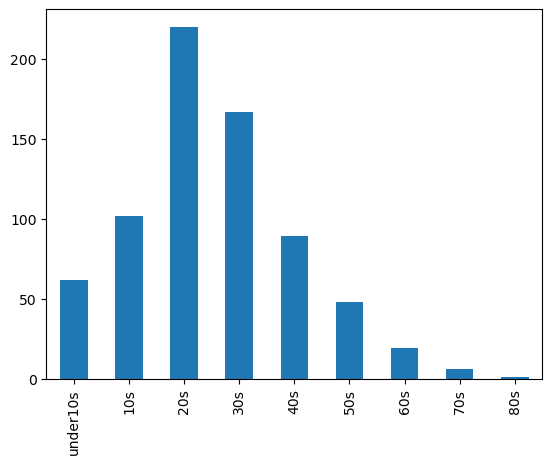

In [19]:
age_FDT.value_counts().plot(kind='bar')

### (2) 상대도수분포표(Relative Frequency Distribution Table)
* 상대도수: 계급의 도수 / 전체 도수의 합계, 어떤 계급의 도수가 전체 도수에서 몇 % 를 차지하는지 나타내는 값 (분포의 비중을 보는 것)
* 상대도수분포표: 모든 계급의 상대도수를 구해서 더한 것

In [20]:
fdt_df = pd.DataFrame(age_FDT.value_counts())
fdt_df

,count
under10s,62
10s,102
20s,220
30s,167
40s,89
50s,48
60s,19
70s,6
80s,1


In [21]:
# 상대도수분포표 만들기
# 상대도수: 계급의 도수 / 전체 도수의 합계

In [22]:
fdt_df['count'] / fdt_df['count'].sum()

under10s    0.086835
10s         0.142857
20s         0.308123
30s         0.233894
40s         0.124650
50s         0.067227
60s         0.026611
70s         0.008403
80s         0.001401
Name: count, dtype: float64

In [23]:
round(fdt_df['count'] / fdt_df['count'].sum(), 3) * 100
# 소수점 셋째자리까지 반올림

under10s     8.7
10s         14.3
20s         30.8
30s         23.4
40s         12.5
50s          6.7
60s          2.7
70s          0.8
80s          0.1
Name: count, dtype: float64

In [24]:
fdt_df['rfdt'] = round(fdt_df['count'] / fdt_df['count'].sum(), 3) * 100

In [25]:
fdt_df

,count,rfdt
under10s,62,8.7
10s,102,14.3
20s,220,30.8
30s,167,23.4
40s,89,12.5
50s,48,6.7
60s,19,2.7
70s,6,0.8
80s,1,0.1


### (3) 계급 구간 설정 - 구간화가 필요한 데이터에서 계급의 개수는 몇 개로?
* 스터지스 공식: 도수분포표나 히스토그램을 만들 때 계급의 수가 적당한지 판단하는 공식
* 전체 데이터 개수를 $ 2^n $ 이라 하고, 그때 계급 수를 n+1 한다.

In [28]:
len(age['Age'])

891

In [29]:
# 891은 2의 몇 승?
n = math.log(891, 2)
print(round(n)+1)

11


## 3) 산포도(Variability) 

데이터의 퍼짐 정도

평균만 보면 데이터 특징을 알기 어렵습니다.

예를 들어

A : [50, 50, 50, 50]
B : [10, 50, 90, 50]

평균은 같지만 데이터 분포는 완전히 다릅니다.

이러한 퍼짐 정도를 측정하는 것이

- 분산 (Variance)
- 표준편차 (Standard Deviation)

입니다.


### (1) 편차(deviation)
* 데이터와 평균이 떨어진 거리, 데이터와 평균 값 과의 차이
* 데이터 - 평균값

In [30]:
a['평균'] = a['표본'].mean()
a

,표본,평균
0,2,5.0
1,3,5.0
2,3,5.0
3,4,5.0
4,4,5.0
5,5,5.0
6,7,5.0
7,7,5.0
8,7,5.0
9,8,5.0


In [31]:
a['편차'] = a['표본'] - a['평균']
a

,표본,평균,편차
0,2,5.0,-3.0
1,3,5.0,-2.0
2,3,5.0,-2.0
3,4,5.0,-1.0
4,4,5.0,-1.0
5,5,5.0,0.0
6,7,5.0,2.0
7,7,5.0,2.0
8,7,5.0,2.0
9,8,5.0,3.0


In [32]:
# 전체 데이터의 편차의 합 0
a['편차'].sum()

np.float64(0.0)

### (2) 분산(variance): 편차 제곱의 합 / 데이터 수
* 평균으로부터 떨어진 정도가 잘 보일 수 있도록 고안된 지표
* 편차의 합은 양수와 음수가 합쳐져서 0이 되기 때문에 각 데이터가 평균으로부터 얼마나 떨어져 있는지 알 수 없어서 편차 제곱의 합인 분산을 사용함
* 모분산: $ \sigma^2 $
$$ \sigma^2 = {\sum(x_i-\mu)^2 \over N} $$
* 표본분산: $ s^2 $
$$ s^2 = {\sum(x_i-\bar{x})^2 \over n-1} $$

In [33]:
# 분산: 편차제곱의 합 / 데이터 수
a['편차제곱'] = a['편차'] ** 2
a

,표본,평균,편차,편차제곱
0,2,5.0,-3.0,9.0
1,3,5.0,-2.0,4.0
2,3,5.0,-2.0,4.0
3,4,5.0,-1.0,1.0
4,4,5.0,-1.0,1.0
5,5,5.0,0.0,0.0
6,7,5.0,2.0,4.0
7,7,5.0,2.0,4.0
8,7,5.0,2.0,4.0
9,8,5.0,3.0,9.0


In [34]:
a['모분산'] = a['편차제곱'].sum() / len(a['편차제곱'])
a

,표본,평균,편차,편차제곱,모분산
0,2,5.0,-3.0,9.0,4.0
1,3,5.0,-2.0,4.0,4.0
2,3,5.0,-2.0,4.0,4.0
3,4,5.0,-1.0,1.0,4.0
4,4,5.0,-1.0,1.0,4.0
5,5,5.0,0.0,0.0,4.0
6,7,5.0,2.0,4.0,4.0
7,7,5.0,2.0,4.0,4.0
8,7,5.0,2.0,4.0,4.0
9,8,5.0,3.0,9.0,4.0


In [35]:
a['표본'].var()

np.float64(4.444444444444445)

표본분산 .var()

In [37]:
a['표본분산'] = a['편차제곱'].sum() / (len(a['편차제곱']) - 1)
a

,표본,평균,편차,편차제곱,모분산,표본분산
0,2,5.0,-3.0,9.0,4.0,4.444444
1,3,5.0,-2.0,4.0,4.0,4.444444
2,3,5.0,-2.0,4.0,4.0,4.444444
3,4,5.0,-1.0,1.0,4.0,4.444444
4,4,5.0,-1.0,1.0,4.0,4.444444
5,5,5.0,0.0,0.0,4.0,4.444444
6,7,5.0,2.0,4.0,4.0,4.444444
7,7,5.0,2.0,4.0,4.0,4.444444
8,7,5.0,2.0,4.0,4.0,4.444444
9,8,5.0,3.0,9.0,4.0,4.444444


### (3) 표준편차(Standard Diviation): 분산의 제곱근
* 분산은 평균으로부터의 차를 알기 쉽지만 2가지 문제가 있다.
    * 단위가 본래 단위의 제곱이 되면서 값이 너무 커지게 된다.
    * 표준편차는 제곱으로 커진 값에 루트를 씌워 다시 원래 단위로 돌려 놓은 지표다.
    
* 모집단의 표준편차 $ \sigma $<br>
* $ \sigma = \sqrt{\sum(x_1-\mu)^2 \over N} $ <br>

* 표본집단의 표준편차 $ s $<br>
* $ s = \sqrt{\sum(x_1-\bar{x})^2 \over n-1} $ <br>

In [38]:
a['표준편차'] = a['모분산'].apply(math.sqrt)
a

,표본,평균,편차,편차제곱,모분산,표본분산,표준편차
0,2,5.0,-3.0,9.0,4.0,4.444444,2.0
1,3,5.0,-2.0,4.0,4.0,4.444444,2.0
2,3,5.0,-2.0,4.0,4.0,4.444444,2.0
3,4,5.0,-1.0,1.0,4.0,4.444444,2.0
4,4,5.0,-1.0,1.0,4.0,4.444444,2.0
5,5,5.0,0.0,0.0,4.0,4.444444,2.0
6,7,5.0,2.0,4.0,4.0,4.444444,2.0
7,7,5.0,2.0,4.0,4.0,4.444444,2.0
8,7,5.0,2.0,4.0,4.0,4.444444,2.0
9,8,5.0,3.0,9.0,4.0,4.444444,2.0


In [39]:
a['표본표준편차'] = a['표본분산'].apply(math.sqrt)
a

,표본,평균,편차,편차제곱,모분산,표본분산,표준편차,표본표준편차
0,2,5.0,-3.0,9.0,4.0,4.444444,2.0,2.108185
1,3,5.0,-2.0,4.0,4.0,4.444444,2.0,2.108185
2,3,5.0,-2.0,4.0,4.0,4.444444,2.0,2.108185
3,4,5.0,-1.0,1.0,4.0,4.444444,2.0,2.108185
4,4,5.0,-1.0,1.0,4.0,4.444444,2.0,2.108185
5,5,5.0,0.0,0.0,4.0,4.444444,2.0,2.108185
6,7,5.0,2.0,4.0,4.0,4.444444,2.0,2.108185
7,7,5.0,2.0,4.0,4.0,4.444444,2.0,2.108185
8,7,5.0,2.0,4.0,4.0,4.444444,2.0,2.108185
9,8,5.0,3.0,9.0,4.0,4.444444,2.0,2.108185


In [40]:
a['표본'].std()

np.float64(2.1081851067789197)

In [41]:
a['표본'].describe()

count    10.000000
mean      5.000000
std       2.108185
min       2.000000
25%       3.250000
50%       4.500000
75%       7.000000
max       8.000000
Name: 표본, dtype: float64

## 4) 표본 분산과 자유도 - 표본표준편차에서 n-1로 분모를 사용하는 이유
* 평균을 유지하기 위해
* 자유도(degrees of freedom)


In [5]:
import numpy as np

In [1]:
a = [2,3,4,5,6]

In [2]:
# 모집단의 평균
(2+3+4+5+6) / 5

4.0

In [7]:
# 표본집단의 평균
b = np.array([4,6,6,3, 1])
b.mean()

np.float64(4.0)

## 5) 표준화 (Standardization)  
### (1) 표준점수 (Standard Score, Z-score)

**표준점수(Z-score)**는 데이터 값이 **평균에서 얼마나 떨어져 있는지를 나타내는 지표**입니다.  
즉, 특정 데이터가 **평균에서 몇 표준편차(Standard Deviation)** 만큼 떨어져 있는지를 의미합니다.

이를 통해 데이터의 **상대적인 위치(relative position)**를 이해할 수 있습니다.



### (2) 모집단의 표준점수

모집단의 평균과 표준편차를 알고 있을 때 사용하는 공식입니다.

$
Z = \frac{x_i - \mu}{\sigma}
$

- $x_i$ : 데이터 값  
- $\mu$ : 모집단 평균  
- $\sigma$ : 모집단 표준편차  



### (3) 표본의 표준점수

표본 데이터에서는 **표본 평균과 표본 표준편차**를 사용합니다.

$
Z = \frac{x_i - \bar{x}}{s}
$

- $x_i$ : 데이터 값  
- $\bar{x}$ : 표본 평균  
- $s$ : 표본 표준편차  



### (4) Z-score의 해석

Z-score 값은 다음과 같이 해석할 수 있습니다.

| Z-score | 의미 |
|---|---|
| $Z = 0$ | 평균과 동일 |
| $Z > 0$ | 평균보다 큰 값 |
| $Z < 0$ | 평균보다 작은 값 |
| $|Z|$가 클수록 | 평균에서 멀리 떨어진 값 |

예

- $Z = 1$ → 평균보다 **1 표준편차 위**
- $Z = -2$ → 평균보다 **2 표준편차 아래**



### (5) 표준화를 사용하는 이유

데이터 분석에서는 **서로 다른 단위를 가진 데이터를 비교해야 하는 경우**가 많습니다.

예

- 키 (cm)
- 몸무게 (kg)
- 시험 점수

이처럼 **단위가 다른 데이터는 직접 비교하기 어렵습니다.**

따라서 **표준화(Z-score)** 를 사용하여 데이터를 **같은 기준으로 변환**합니다.

표준화를 하면 데이터는 다음과 같은 특성을 가지게 됩니다.

- 평균 = $0$
- 표준편차 = $1$

이를 통해

- 서로 다른 변수 비교
- 이상치 탐지
- 머신러닝 모델 학습

등에 활용할 수 있습니다.

## 6) 공분산 (Covariance)

지금까지 우리는 **하나의 변수 분포**를 설명하는 통계량을 배웠습니다.

| 통계량 | 의미 |
|---|---|
| 평균 | 데이터의 중심 |
| 분산 | 데이터의 퍼짐 |
| 표준편차 | 퍼짐의 크기 |

하지만 실제 데이터 분석에서는 **두 변수의 관계**가 중요합니다.

예를 들어 다음과 같은 데이터가 있다고 가정해 봅시다.

| 공부시간 | 시험점수 |
|---|---|
|2|60|
|4|70|
|6|80|

공부시간이 증가하면 시험점수도 증가합니다.

이처럼 **두 변수의 관계를 나타내는 지표를 공분산(Covariance)** 이라고 합니다.



### (1) 공분산의 의미

공분산은 두 변수의 **변화 방향 관계**를 나타냅니다.

| 공분산 값 | 의미 |
|---|---|
| $Cov(X,Y) > 0$ | 두 변수는 같은 방향으로 움직임 |
| $Cov(X,Y) < 0$ | 두 변수는 반대 방향으로 움직임 |
| $Cov(X,Y) = 0$ | 두 변수 사이에 선형 관계가 없음 |

예

- 공부시간 ↑ → 시험점수 ↑ → 공분산 양수  
- 온도 ↑ → 난방비 ↓ → 공분산 음수  



### (2) 공분산 공식

#### 가. 모집단 공분산

$
Cov(X,Y)=\frac{\sum (x_i-\mu_x)(y_i-\mu_y)}{N}
$

#### 나. 표본 공분산

$
Cov(X,Y)=\frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{n-1}
$



### (3) 기호 설명

| 기호 | 의미 |
|---|---|
| $x_i$ | X 변수의 데이터 |
| $y_i$ | Y 변수의 데이터 |
| $\mu_x$ | X의 모집단 평균 |
| $\mu_y$ | Y의 모집단 평균 |
| $\bar{x}$ | X의 표본 평균 |
| $\bar{y}$ | Y의 표본 평균 |
| $n$ | 표본 크기 |



### (4) 공분산 계산 과정

예시 데이터

| X | Y |
|---|---|
|2|1|
|4|3|
|6|5|

#### 가. 평균 계산

$
\bar{x}=4
$

$
\bar{y}=3
$



#### 나. 평균과 차이 계산

| X | Y | $X-\bar{X}$ | $Y-\bar{Y}$ |
|---|---|---|---|
|2|1|-2|-2|
|4|3|0|0|
|6|5|2|2|



#### 다. 편차 곱

| $(X-\bar{X})(Y-\bar{Y})$ |
|---|
|4|
|0|
|4|



#### 라. 합

$
\sum (X-\bar{X})(Y-\bar{Y}) = 8
$



#### 마. 공분산

$
Cov(X,Y)=\frac{8}{3-1}=4
$



### (5) 공분산의 문제점

공분산은 **단위의 영향을 받습니다.**

예

| 변수 | 단위 |
|---|---|
| 키 | cm |
| 몸무게 | kg |

단위가 바뀌면 공분산 값도 달라집니다.

따라서 변수 간 관계를 비교하기 어렵습니다.

이 문제를 해결하기 위해 사용하는 지표가 **상관계수(Correlation)** 입니다.

## 공분산 그래프 예시

공분산은 두 변수의 **변화 방향**을 나타낸다.

$
Cov(X,Y) = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{n-1}
$

공분산 값에 따라 데이터의 관계는 다음과 같이 나타난다.

| 경우 | 의미 |
|---|---|
| 양의 공분산 | X 증가 → Y 증가 |
| 음의 공분산 | X 증가 → Y 감소 |
| 공분산 ≈ 0 | 선형 관계 없음 |
| 비선형 관계 | 관계는 있지만 공분산은 작음 |

아래 그래프는 공분산의 대표적인 4가지 형태를 보여준다.

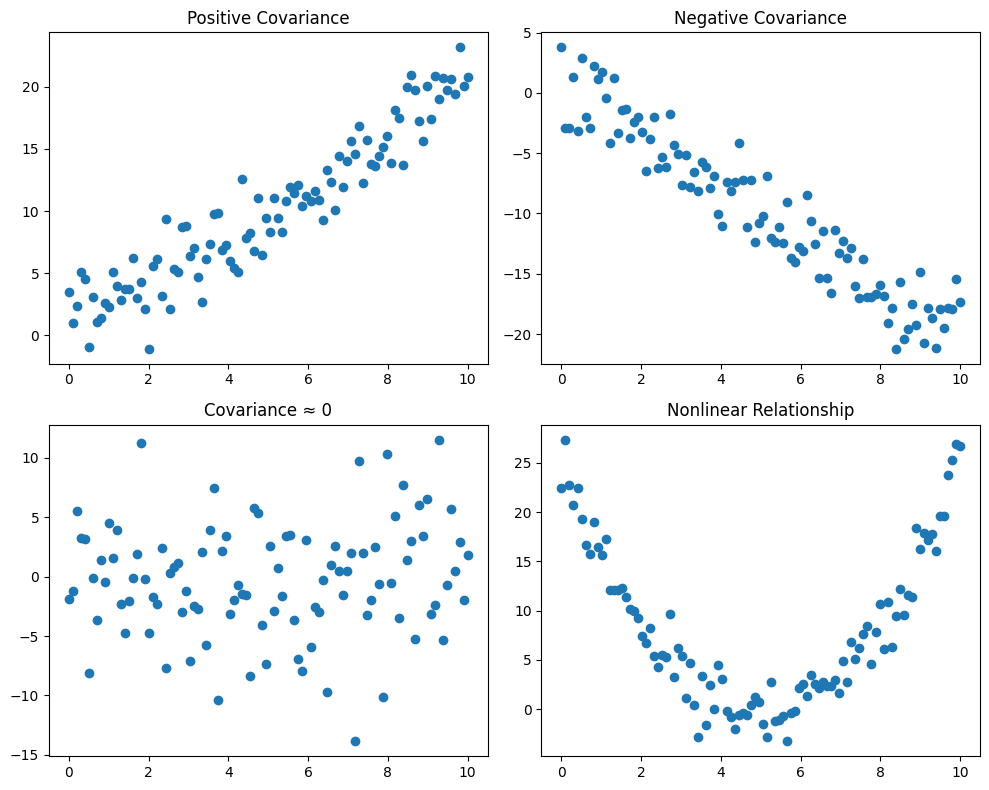

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

x = np.linspace(0,10,100)

# 1 양의 공분산
y1 = 2*x + np.random.normal(0,2,100)

# 2 음의 공분산
y2 = -2*x + np.random.normal(0,2,100)

# 3 공분산 ≈ 0
y3 = np.random.normal(0,5,100)

# 4 비선형 관계
y4 = (x-5)**2 + np.random.normal(0,2,100)

fig, ax = plt.subplots(2,2, figsize=(10,8))

ax[0,0].scatter(x,y1)
ax[0,0].set_title("Positive Covariance")

ax[0,1].scatter(x,y2)
ax[0,1].set_title("Negative Covariance")

ax[1,0].scatter(x,y3)
ax[1,0].set_title("Covariance ≈ 0")

ax[1,1].scatter(x,y4)
ax[1,1].set_title("Nonlinear Relationship")

plt.tight_layout()
plt.show()


## 7) 상관계수 (Correlation)

상관계수는 공분산을 **표준편차로 나누어 표준화한 값**입니다.

$
r=\frac{Cov(X,Y)}{\sigma_X\sigma_Y}
$



### (1) 상관계수 특징

| 값 | 의미 |
|---|---|
| $r=1$ | 완전한 양의 상관관계 |
| $r=0$ | 상관관계 없음 |
| $r=-1$ | 완전한 음의 상관관계 |

상관계수의 범위

$
-1 \le r \le 1
$



### (2) 공분산과 상관계수 비교

| 구분 | 공분산 | 상관계수 |
|---|---|---|
| 의미 | 두 변수의 방향 관계 | 두 변수의 강도 + 방향 |
| 범위 | 제한 없음 | $-1 \sim 1$ |
| 단위 영향 | 받음 | 받지 않음 |



### (3) 데이터 분석에서 활용

공분산과 상관계수는 다음과 같은 분석에서 사용됩니다.

- 변수 관계 분석
- 머신러닝 특징 선택
- 금융 포트폴리오 분석
- 차원 축소 (PCA)

특히 PCA에서는 **공분산 행렬(Covariance Matrix)** 이 사용됩니다.

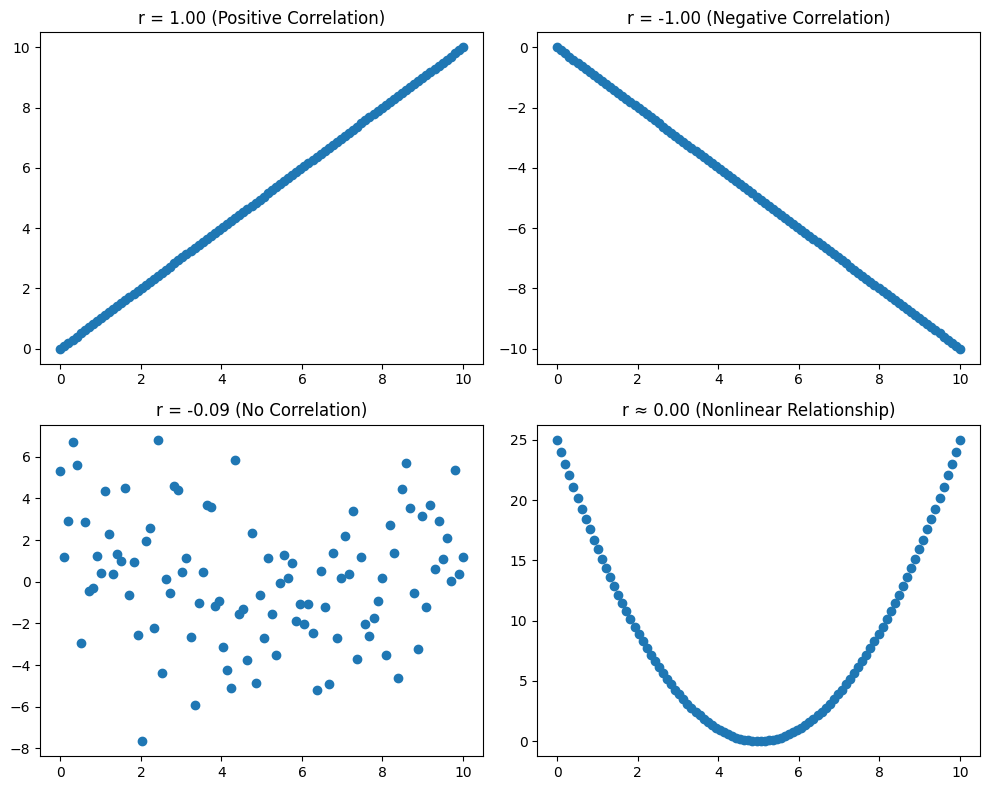

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

x = np.linspace(0,10,100)

# 1 완전한 양의 상관관계
y1 = x

# 2 완전한 음의 상관관계
y2 = -x

# 3 상관관계 없음
y3 = np.random.normal(0,3,100)

# 4 비선형 관계 (상관계수 ≈ 0)
y4 = (x-5)**2

# 상관계수 계산
r1 = np.corrcoef(x,y1)[0,1]
r2 = np.corrcoef(x,y2)[0,1]
r3 = np.corrcoef(x,y3)[0,1]
r4 = np.corrcoef(x,y4)[0,1]

fig, ax = plt.subplots(2,2, figsize=(10,8))

ax[0,0].scatter(x,y1)
ax[0,0].set_title(f"r = {r1:.2f} (Positive Correlation)")

ax[0,1].scatter(x,y2)
ax[0,1].set_title(f"r = {r2:.2f} (Negative Correlation)")

ax[1,0].scatter(x,y3)
ax[1,0].set_title(f"r = {r3:.2f} (No Correlation)")

ax[1,1].scatter(x,y4)
ax[1,1].set_title(f"r ≈ {r4:.2f} (Nonlinear Relationship)")

plt.tight_layout()
plt.show()

## 8) PCA (Principal Component Analysis)

주성분분석(PCA)은 여러 변수로 구성된 데이터를 **소수의 새로운 변수로 변환하여 차원을 축소하는 방법**이다.

PCA는 **데이터의 분산이 가장 큰 방향을 찾아 새로운 축(주성분)을 만든다.**



### (1) PCA와 공분산

PCA는 **공분산 행렬(Covariance Matrix)** 을 기반으로 계산된다.

공분산은 두 변수의 **변화 방향 관계**를 나타낸다.

$
Cov(X,Y)=\frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{n-1}
$

여러 변수의 공분산을 정리하면 **공분산 행렬**이 된다.

예를 들어 두 변수의 공분산 행렬은 다음과 같다.

$
\begin{bmatrix}
Var(X) & Cov(X,Y) \\
Cov(X,Y) & Var(Y)
\end{bmatrix}
$



### (2) PCA 계산 과정

PCA는 다음 과정을 통해 수행된다.

1. 데이터 표준화 (평균 0, 분산 1)
2. 공분산 행렬 계산
3. 공분산 행렬의 **고유값(Eigenvalue)** 과 **고유벡터(Eigenvector)** 계산
4. 고유값이 큰 순서대로 주성분 선택
5. 데이터 차원 축소



### (3) 설명력 (Explained Variance Ratio)

PCA에서 각 주성분은 데이터 분산의 일부를 설명한다.

주성분의 설명력은 다음과 같이 계산된다.

$
Explained\ Variance\ Ratio =
\frac{\lambda_i}{\sum \lambda}
$

여기서

- $\lambda_i$ : i번째 고유값



### (4) 누적 설명력

차원 축소 시 보통 **누적 설명력 80~90% 이상**이 되도록 주성분을 선택한다.

예

| PC | 설명력 |
|---|---|
| PC1 | 52% |
| PC2 | 28% |
| PC3 | 12% |

누적 설명력

$
52 + 28 = 80\%
$

따라서 **PC1 + PC2만 사용해도 대부분의 정보를 유지할 수 있다.**



### (5) PCA 활용

PCA는 다음과 같은 분석에서 활용된다.

- 차원 축소
- 데이터 시각화
- 노이즈 제거
- 머신러닝 전처리

wine 데이터를 이용한 PCA 예제

In [10]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 데이터 로드
wine = load_wine()
X = wine.data
cols = wine.feature_names

df = pd.DataFrame(X, columns=cols)

# 데이터 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA 수행
pca = PCA()
pca.fit(X_scaled)

# R 스타일 PCA 결과 계산
std_dev = np.sqrt(pca.explained_variance_)
prop_var = pca.explained_variance_ratio_
cum_var = np.cumsum(prop_var)

# 결과 DataFrame
pca_summary = pd.DataFrame(
    [std_dev, prop_var, cum_var],
    index=["Standard deviation",
           "Proportion of Variance",
           "Cumulative Proportion"],
    columns=[f"PC{i+1}" for i in range(len(std_dev))]
)

print("Importance of components:")
pca_summary

Importance of components:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
Standard deviation,2.175417,1.584639,1.205920,0.961335,0.926309,0.803295,0.744407,0.592002,0.538992,0.502315,0.476513,0.411975,0.322431
Proportion of Variance,0.361988,0.192075,0.111236,0.070690,0.065633,0.049358,0.042387,0.026807,0.022222,0.019300,0.017368,0.012982,0.007952
Cumulative Proportion,0.361988,0.554063,0.665300,0.735990,0.801623,0.850981,0.893368,0.920175,0.942397,0.961697,0.979066,0.992048,1.000000


* PC5번째까지 사용해서 할 수 있음 (80%가 기준이기 때문)

### (6) PCA 차원 축소 설명

이번 예제에서는 **Wine 데이터셋**을 사용하였다.

Wine 데이터는 총 **13개의 변수(feature)** 로 구성되어 있다.

즉 원래 데이터의 차원은

$
13 \; dimensions
$

이다.

PCA를 적용하면 이 13개의 변수를 **주성분(Principal Component)** 이라는 새로운 축으로 변환한다.

주성분은 다음 특징을 가진다.

- 서로 **직교(orthogonal)** 한다.
- 데이터의 **분산이 가장 큰 방향**을 나타낸다.

**PC1 =
0.14*alcohol
+0.24*malic_acid
+0.37*flavanoids + ...**
> PC1 = 원래 변수들의 가중합

PCA 결과에서는 보통 **설명력(Explained Variance Ratio)** 을 기준으로 몇 개의 주성분을 사용할지 결정한다.

예를 들어

| Principal Component | Explained Variance |
|---|---|
| PC1 | 36% |
| PC2 | 18% |
| PC3 | 12% |

누적 설명력은

$
36 + 18 + 12 = 66\%
$

이 된다.

즉 **13개의 변수 대신 3개의 주성분만 사용해도 전체 정보의 약 66%를 설명할 수 있다.**

따라서

$
13 \rightarrow 3
$

으로 차원을 축소할 수 있다.

이처럼 PCA는 **정보 손실을 최소화하면서 데이터 차원을 줄이는 방법**이다.

# 2. Boxplot과 이상치

머신러닝에서는 **이상치(outlier)** 를 빨리 확인하는 것이 중요합니다.

- 모델 성능 저하 가능성 확인
- 데이터 품질 점검
- 스케일링 방식 선택에 도움

Boxplot은 데이터 분포를 빠르게 이해할 수 있는 그래프입니다.

구성

- Median (중앙값)
- Q1
- Q3
- IQR
- 이상치(outlier)

IQR = Q3 - Q1


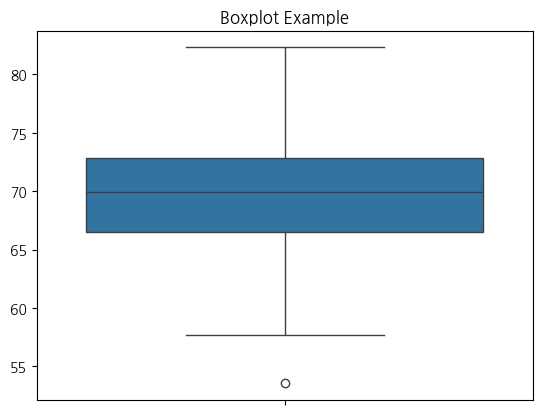

In [9]:

sns.boxplot(data)
plt.title("Boxplot Example")
plt.show()


# 3. 데이터 분포 (Distribution)

## 1) 데이터 분포 개념(Data Distribution)

통계에서 가장 중요한 개념 중 하나는 **데이터 분포**입니다.

데이터가 어떻게 퍼져 있는지에 따라 분석 방법이 달라집니다.

데이터 분포란 **데이터 값들이 어떤 형태로 퍼져 있는지를 나타내는 것**이다.  
즉, 데이터가 특정 값 주변에 많이 모여 있는지, 넓게 퍼져 있는지, 또는 한쪽으로 치우쳐 있는지를 설명하는 개념이다.

데이터 분석에서는 단순히 평균만 보는 것이 아니라 **데이터가 어떤 분포를 가지는지**를 이해하는 것이 매우 중요하다.  
왜냐하면 통계 분석 방법들은 대부분 **데이터의 분포 형태를 가정**하고 있기 때문이다.

---

### (1) 데이터 분포를 보는 이유

데이터 분포를 이해하면 다음과 같은 정보를 얻을 수 있다.

- 데이터가 어느 값 주변에 많이 모여 있는지
- 데이터가 얼마나 넓게 퍼져 있는지
- 데이터가 한쪽으로 치우쳐 있는지
- 이상치(outlier)가 존재하는지

이러한 정보는 이후 수행하는 **통계 분석이나 머신러닝 모델링에 중요한 영향을 준다.**

---

### (2) 데이터 분포를 확인하는 방법

데이터 분포는 보통 다음과 같은 시각화 방법을 사용하여 확인한다.

- 히스토그램 (Histogram)
- 커널 밀도 그래프 (KDE Plot)
- 박스플롯 (Boxplot)

이러한 그래프를 통해 데이터가 어떤 형태로 분포하고 있는지 직관적으로 파악할 수 있다.

## 2) 대표적인 데이터 분포 형태

데이터 분포는 여러 가지 형태를 가질 수 있다.

### (1) 정규분포 (Normal Distribution)

가장 대표적인 분포로 **종 모양(Bell shape)**의 대칭적인 형태를 가진다.

특징

- 평균 = 중앙값 = 최빈값
- 좌우가 대칭
- 많은 자연현상이 정규분포를 따른다.

예

- 사람의 키
- 시험 점수
- 측정 오차

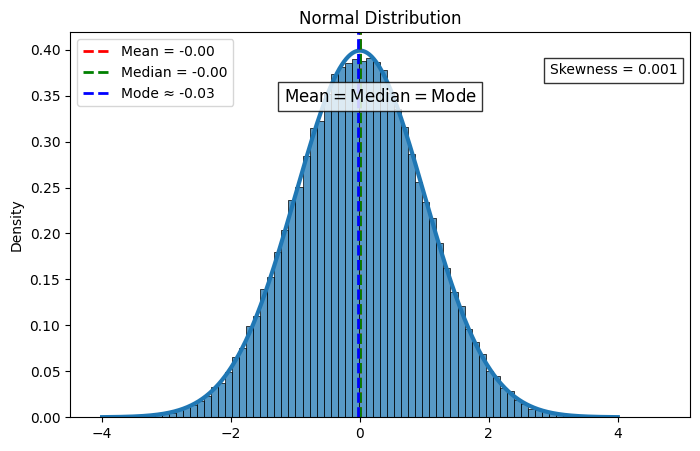

In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, gaussian_kde, norm

# 샘플 수 크게 증가
data = np.random.normal(0,1,100000)

# 통계값 계산
mean_val = np.mean(data)
median_val = np.median(data)
skew_val = skew(data)

# KDE 기반 mode
kde = gaussian_kde(data)
x_vals = np.linspace(min(data), max(data), 1000)
mode_val = x_vals[np.argmax(kde(x_vals))]

# 그래프
plt.figure(figsize=(8,5))

# 히스토그램
sns.histplot(data, stat="density", bins=80)

# 이론 정규분포 곡선
x = np.linspace(-4,4,1000)
plt.plot(x, norm.pdf(x,0,1), linewidth=3)

# 평균 / 중앙값 / 최빈값
plt.axvline(mean_val, color="red", linestyle="--", linewidth=2,
            label=f"Mean = {mean_val:.2f}")

plt.axvline(median_val, color="green", linestyle="--", linewidth=2,
            label=f"Median = {median_val:.2f}")

plt.axvline(mode_val, color="blue", linestyle="--", linewidth=2,
            label=f"Mode ≈ {mode_val:.2f}")

# skew 표시
plt.text(
    0.98, 0.92,
    f"Skewness = {skew_val:.3f}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

# 관계 표시
plt.text(
    0.5, 0.82,
    r"$\mathrm{Mean} = \mathrm{Median} = \mathrm{Mode}$",
    transform=plt.gca().transAxes,
    ha="center",
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.title("Normal Distribution")
plt.legend()
plt.show()


### (2) 오른쪽으로 치우친 분포 (Right-skewed Distribution)

데이터가 **오른쪽 방향으로 긴 꼬리(right tail)**를 가지는 분포이다.  
이를 **양의 왜도(Positive Skewness)**를 가진 분포라고도 한다.

특징

- 최빈값 < 중앙값 < 평균
- 오른쪽 방향으로 긴 꼬리를 가진다.
- 큰 값(outlier)이 일부 존재하여 평균이 오른쪽으로 이동한다.
- 왜도(skewness)가 **0보다 크다**.

$
\text{Mode} < \text{Median} < \text{Mean}
$

$
\text{Skewness} > 0
$

예

- 소득 분포
- 부동산 가격
- 회사 매출
- 인터넷 트래픽

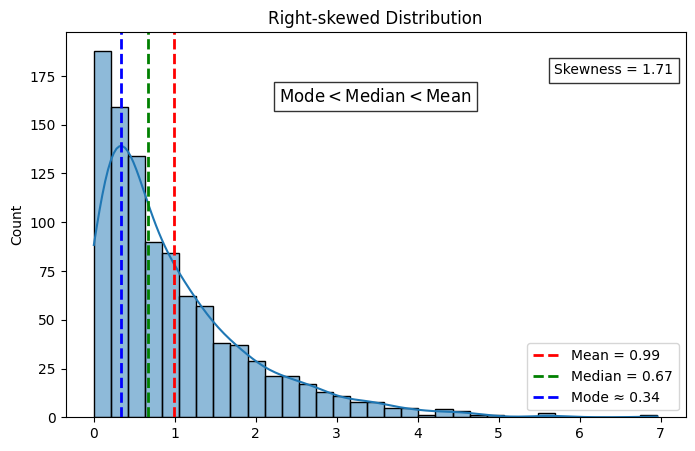

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, gaussian_kde

# 오른쪽으로 치우친 분포
data = np.random.exponential(scale=1, size=1000)

# 통계값 계산
mean_val = np.mean(data)
median_val = np.median(data)
skew_val = skew(data)

# KDE 기반 최빈값 (mode 근사)
kde = gaussian_kde(data)
x_vals = np.linspace(min(data), max(data), 1000)
mode_val = x_vals[np.argmax(kde(x_vals))]

# 그래프
plt.figure(figsize=(8,5))
sns.histplot(data, kde=True)

# 평균 / 중앙값 / 최빈값 표시 (색상 구분)
plt.axvline(mean_val, color="red", linestyle="--", linewidth=2,
            label=f"Mean = {mean_val:.2f}")

plt.axvline(median_val, color="green", linestyle="--", linewidth=2,
            label=f"Median = {median_val:.2f}")

plt.axvline(mode_val, color="blue", linestyle="--", linewidth=2,
            label=f"Mode ≈ {mode_val:.2f}")

# skew 값 표시
plt.text(
    0.98, 0.92,
    f"Skewness = {skew_val:.2f}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

# Mode < Median < Mean 관계 표시
plt.text(
    0.5, 0.82,
    r"$\mathrm{Mode} < \mathrm{Median} < \mathrm{Mean}$",
    transform=plt.gca().transAxes,
    ha="center",
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.title("Right-skewed Distribution")
plt.legend()
plt.show()

### (3) 로그 변환 (Log Transformation)

데이터가 **오른쪽으로 길게 늘어진 분포(Right Skewed Distribution)** 를 가질 때  
로그 변환을 사용하면 분포를 더 **대칭적인 형태(정규분포에 가까운 형태)** 로 만들 수 있습니다.

로그 변환은 큰 값의 영향을 줄여 **이상치의 영향력을 완화**하는 효과가 있습니다.

예를 들어 **소득, 거래금액, 매출 데이터**처럼 일부 값이 매우 큰 경우에는  
로그 변환을 통해 분포를 더 안정적인 형태로 만들 수 있습니다.



### 로그 변환 방법

일반적으로 다음과 같은 형태로 변환합니다.
x → log(x)

만약 데이터에 **0이 포함되어 있다면** 다음과 같은 변환을 사용합니다.
x → log(x + 1)



### 로그 변환의 효과

로그 변환을 적용하면 다음과 같은 변화가 나타납니다.

- 큰 값이 압축됨
- 분포의 오른쪽 꼬리가 줄어듦
- 분포가 더 대칭적인 형태로 변함

예시

원본 데이터  
[10, 12, 15, 20, 25, 30, 300]  

로그 변환 후  
[2.30, 2.48, 2.71, 3.00, 3.22, 3.40, 5.70]  

큰 값의 영향이 줄어든 것을 확인할 수 있습니다.



### 머신러닝에서의 활용

로그 변환은 다음과 같은 데이터에서 자주 사용됩니다.

- 소득 데이터
- 거래 금액
- 판매량
- 방문 수
- 금융 거래 데이터

이러한 데이터는 보통 **Right Skewed Distribution**을 가지기 때문에  
로그 변환을 통해 **데이터 분포를 안정화하고 모델 학습을 더 효과적으로 만들 수 있습니다.**



### 정리



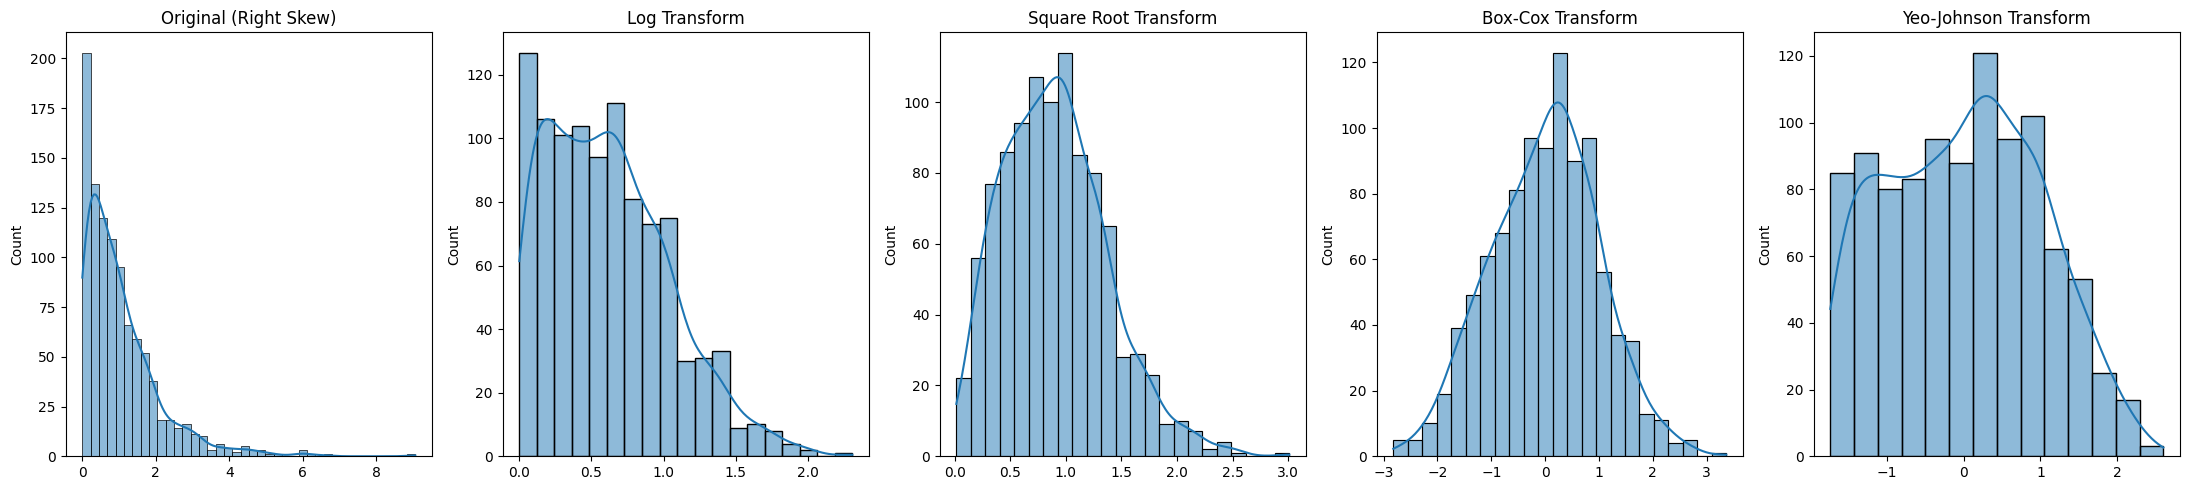

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

# right-skew 데이터 생성
data = np.random.exponential(scale=1, size=1000)

# 변환들
log_data = np.log(data + 1)
sqrt_data = np.sqrt(data)

# Box-Cox (양수 데이터 필요)
boxcox = PowerTransformer(method="box-cox")
boxcox_data = boxcox.fit_transform(data.reshape(-1,1)).flatten()

# Yeo-Johnson (음수도 가능)
yeojohnson = PowerTransformer(method="yeo-johnson")
yeojohnson_data = yeojohnson.fit_transform(data.reshape(-1,1)).flatten()

# 그래프
fig, ax = plt.subplots(1,5, figsize=(22,5))

sns.histplot(data, kde=True, ax=ax[0])
ax[0].set_title("Original (Right Skew)")

sns.histplot(log_data, kde=True, ax=ax[1])
ax[1].set_title("Log Transform")

sns.histplot(sqrt_data, kde=True, ax=ax[2])
ax[2].set_title("Square Root Transform")

sns.histplot(boxcox_data, kde=True, ax=ax[3])
ax[3].set_title("Box-Cox Transform")

sns.histplot(yeojohnson_data, kde=True, ax=ax[4])
ax[4].set_title("Yeo-Johnson Transform")

plt.tight_layout()
plt.show()


### (4) 왼쪽으로 치우친 분포 (Left-skewed Distribution)

데이터가 **왼쪽 방향으로 긴 꼬리**를 가지는 분포이다.

특징

- 평균 < 중앙값 < 최빈값

예

- 시험 점수 (대부분 높은 경우)

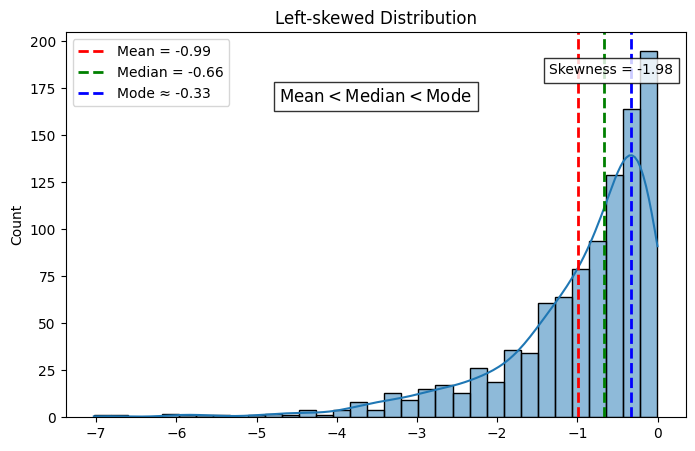

In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, gaussian_kde

# 왼쪽으로 치우친 분포
data = -np.random.exponential(scale=1, size=1000)

# 통계값 계산
mean_val = np.mean(data)
median_val = np.median(data)
skew_val = skew(data)

# KDE 기반 최빈값 (mode 근사)
kde = gaussian_kde(data)
x_vals = np.linspace(min(data), max(data), 1000)
mode_val = x_vals[np.argmax(kde(x_vals))]

# 그래프
plt.figure(figsize=(8,5))
sns.histplot(data, kde=True)

# 평균 / 중앙값 / 최빈값 (색 구분)
plt.axvline(mean_val, color="red", linestyle="--", linewidth=2,
            label=f"Mean = {mean_val:.2f}")

plt.axvline(median_val, color="green", linestyle="--", linewidth=2,
            label=f"Median = {median_val:.2f}")

plt.axvline(mode_val, color="blue", linestyle="--", linewidth=2,
            label=f"Mode ≈ {mode_val:.2f}")

# skew 값 표시
plt.text(
    0.98, 0.92,
    f"Skewness = {skew_val:.2f}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

# Mean < Median < Mode 관계 표시
plt.text(
    0.5, 0.82,
    r"$\mathrm{Mean} < \mathrm{Median} < \mathrm{Mode}$",
    transform=plt.gca().transAxes,
    ha="center",
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.title("Left-skewed Distribution")
plt.legend()
plt.show()

## (5) Left Skewed Distribution 변환

데이터가 **왼쪽으로 길게 늘어진 분포(Left Skewed Distribution)** 를 가질 때  
**제곱 변환(Square Transformation)** 또는 **역수 변환(Reciprocal Transformation)** 을 사용하여  
분포를 **정규분포에 가까운 형태로 변환**할 수 있습니다.

Left Skewed Distribution은 **큰 값이 많고 작은 값이 적은 분포**입니다.

예시
[2, 50, 55, 60, 65, 70, 75]

이 경우 왼쪽 꼬리가 길어 **Left Skewed Distribution**이 됩니다.



## 변환 방법

### 1. 제곱 변환

제곱 변환은 다음과 같이 적용합니다.
x → x²  

큰 값과 작은 값의 차이를 확대하여  
**왼쪽으로 치우친 분포를 완화**할 수 있습니다.



### 2. 역수 변환

역수 변환은 다음과 같이 적용합니다.
x → 1/x  

또는 데이터 안정성을 위해  
x → 1/(x+1)  

형태로 변환하기도 합니다.


## 변환 효과

Left Skew 데이터에 변환을 적용하면 다음과 같은 변화가 나타납니다.

- 분포의 왼쪽 꼬리가 줄어듦
- 데이터 분포가 더 대칭적인 형태로 변화
- 모델 학습 시 안정적인 분포 형성



## 머신러닝에서의 활용

Left Skewed Distribution은 다음과 같은 데이터에서 나타날 수 있습니다.

- 시험 점수
- 고객 만족도 점수
- 제품 품질 점수
- 평점 데이터

이러한 경우 변환을 통해 **모델 성능을 개선할 수 있습니다.**

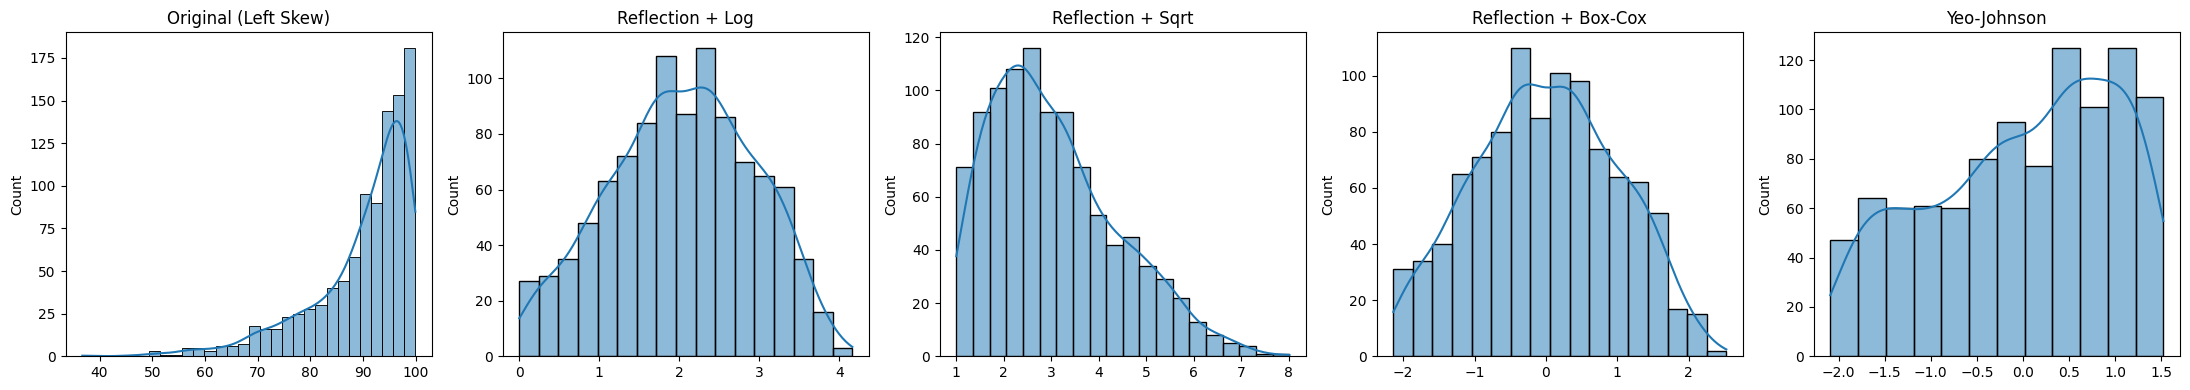

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

# Left-skew 데이터 생성
data = 100 - np.random.exponential(scale=10, size=1000)

# reflection (Left skew → Right skew)
reflected = np.max(data) - data + 1

# 변환들
log_data = np.log(reflected)
sqrt_data = np.sqrt(reflected)

# Box-Cox
boxcox = PowerTransformer(method="box-cox")
boxcox_data = boxcox.fit_transform(reflected.reshape(-1,1)).flatten()

# Yeo-Johnson
yeojohnson = PowerTransformer(method="yeo-johnson")
yeojohnson_data = yeojohnson.fit_transform(data.reshape(-1,1)).flatten()

# 그래프
fig, ax = plt.subplots(1,5, figsize=(22,4))

sns.histplot(data, kde=True, ax=ax[0])
ax[0].set_title("Original (Left Skew)")

sns.histplot(log_data, kde=True, ax=ax[1])
ax[1].set_title("Reflection + Log")

sns.histplot(sqrt_data, kde=True, ax=ax[2])
ax[2].set_title("Reflection + Sqrt")

sns.histplot(boxcox_data, kde=True, ax=ax[3])
ax[3].set_title("Reflection + Box-Cox")

sns.histplot(yeojohnson_data, kde=True, ax=ax[4])
ax[4].set_title("Yeo-Johnson")

plt.tight_layout()
plt.show()

## Skew 종류에 따른 데이터 변환 방법

| Skew 종류 | 분포 특징 | 추천 변환 방법 | 설명 | 예시 데이터 |
|---|---|---|---|---|
| **Right Skew (Positive Skew)** | 오른쪽 꼬리가 길다 | `log(x)` | 가장 일반적으로 사용하는 변환 | 소득, 매출 |
| | | `sqrt(x)` | log보다 완만한 변환 | 방문자 수 |
| | | `Box-Cox` | 최적 λ 자동 계산 | 금융 데이터 |
| | | `Yeo-Johnson` | Box-Cox 확장 (음수 가능) | 일반 머신러닝 데이터 |
| **Left Skew (Negative Skew)** | 왼쪽 꼬리가 길다 | `reflect + log` | reflection 후 log 변환 | 시험 점수 |
| | | `reflect + sqrt` | 완만한 보정 | 만족도 점수 |
| | | `Yeo-Johnson` | 자동 변환 | 일반 머신러닝 데이터 |
| **Strong Outlier** | 이상치 영향 큼 | `log(x+1)` | 큰 값 압축 | 거래 금액 |
| | | `Robust Scaling` | 이상치에 강함 | 금융 데이터 |
| **Normal Distribution** | 대칭 분포 | 변환 불필요 | 모델 학습에 적합 | 자연 데이터 |


### (4) 데이터 분포와 통계 분석

많은 통계 방법은 **정규분포를 가정**하고 있다.

예

- t-test
- ANOVA
- 회귀분석

하지만 실제 데이터는 항상 정규분포를 따르지 않기 때문에  
데이터 분석을 수행하기 전에 **데이터 분포를 확인하는 과정이 매우 중요하다.**

---

### (6) 정리

데이터 분포란 **데이터 값들이 어떤 형태로 퍼져 있는지를 나타내는 개념**이며,  
데이터의 중심, 퍼짐 정도, 치우침, 이상치 등을 이해하는 데 중요한 역할을 한다.

대표적인 분포:

- 정규분포 (Normal Distribution)
- 균등분포 (Uniform)
- 치우친 분포 (Skewed Distribution)

특히 **정규분포는 통계학에서 가장 중요**합니다.
많은 통계 기법은 **데이터가 정규분포를 따른다고 가정**합니다.

# 4. 머신러닝에서의 Feature Scaling

머신러닝에서는 변수의 **단위와 범위가 다르면** 모델이 특정 변수에 더 민감하게 반응할 수 있습니다.

대표적인 스케일링 방법

## 1) Standardization
- 평균을 0, 표준편차를 1로 맞춤
- Z-score 개념과 연결됨
- `StandardScaler` 사용

## 2) MinMax Scaling
- 값을 0~1 범위로 변환
- 이미지, 거리 기반 모델에서 자주 사용
- `MinMaxScaler` 사용

## 3) Robust Scaling
- 중앙값과 IQR 기준으로 변환
- 이상치의 영향을 덜 받음
- `RobustScaler` 사용

정리
- 이상치가 크지 않으면: Standardization
- 범위를 맞추고 싶으면: MinMax Scaling
- 이상치가 많으면: Robust Scaling


In [1]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import pandas as pd

sample = pd.DataFrame({
    'income': [2000, 2200, 2500, 2700, 10000],
    'age': [23, 25, 29, 31, 45]
})

std_scaled = pd.DataFrame(StandardScaler().fit_transform(sample), columns=sample.columns)
minmax_scaled = pd.DataFrame(MinMaxScaler().fit_transform(sample), columns=sample.columns)
robust_scaled = pd.DataFrame(RobustScaler().fit_transform(sample), columns=sample.columns)

print('[원본 데이터]')
display(sample)
print('[StandardScaler]')
display(std_scaled)
print('[MinMaxScaler]')
display(minmax_scaled)
print('[RobustScaler]')
display(robust_scaled)


[원본 데이터]


,income,age
0,2000,23
1,2200,25
2,2500,29
3,2700,31
4,10000,45


[StandardScaler]


,income,age
0,-0.612485,-0.982467
1,-0.547327,-0.723923
2,-0.449590,-0.206835
3,-0.384432,0.051709
4,1.993834,1.861516


[MinMaxScaler]


,income,age
0,0.0000,0.000000
1,0.0250,0.090909
2,0.0625,0.272727
3,0.0875,0.363636
4,1.0000,1.000000


[RobustScaler]


,income,age
0,-1.0,-1.000000
1,-0.6,-0.666667
2,0.0,0.000000
3,0.4,0.333333
4,15.0,2.666667


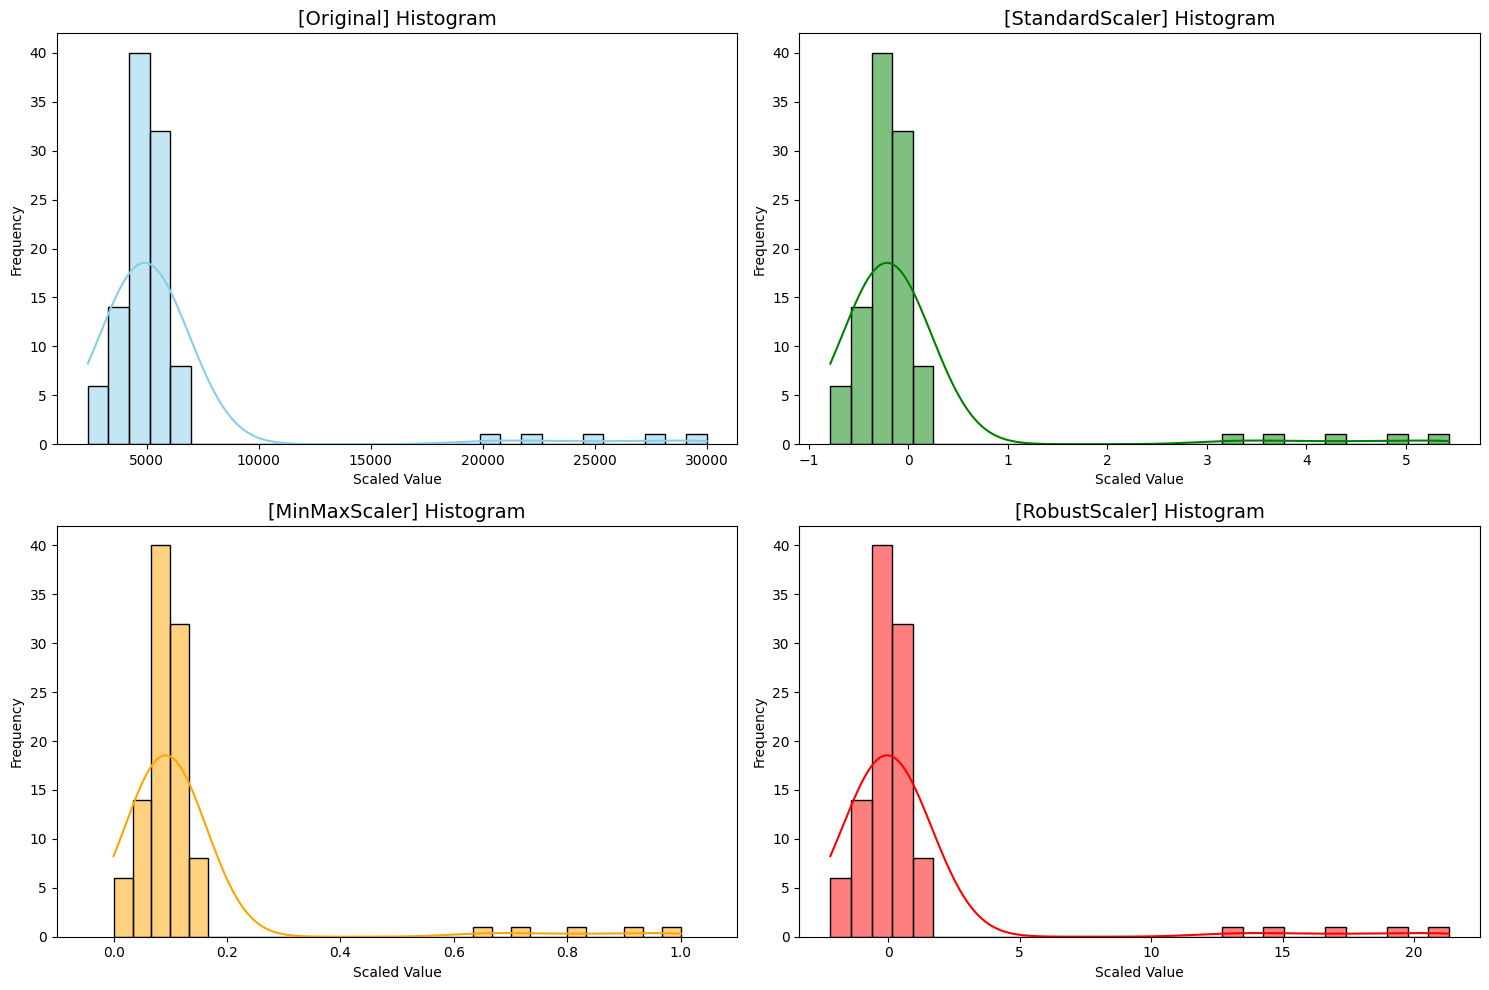

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# 1. 데이터 생성 (100개 + 이상치 5개)
np.random.seed(42)
income = np.concatenate([
    np.random.normal(5000, 1000, 100),  # 정상 데이터
    [20000, 25000, 30000, 28000, 22000] # 이상치
])
df = pd.DataFrame({'income': income})

# 2. 스케일링 적용
scalers = {
    'Original': df['income'].values.reshape(-1, 1),
    'StandardScaler': StandardScaler().fit_transform(df[['income']]),
    'MinMaxScaler': MinMaxScaler().fit_transform(df[['income']]),
    'RobustScaler': RobustScaler().fit_transform(df[['income']])
}

# 3. Histplot 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
colors = ['skyblue', 'green', 'orange', 'red']

for i, (name, data) in enumerate(scalers.items()):
    sns.histplot(data.flatten(), kde=True, ax=axes[i], color=colors[i], bins=30)
    axes[i].set_title(f'[{name}] Histogram', fontsize=14)
    axes[i].set_xlabel('Scaled Value')
    axes[i].set_ylabel('Frequency')
    
    # 이상치 위치를 강조하기 위해 x축 범위 표시
    if name == 'MinMaxScaler':
        axes[i].set_xlim(-0.1, 1.1) # 0~1 범위 강조

plt.tight_layout()
plt.show()

Original: 5,000 근처에 데이터가 몰려 있고, 저 멀리 20,000 이상의 데이터가 떨어져 있는 "Long Tail" 형태를 보입니다.

StandardScaler: 중심이 0 근처에 있지만, 이상치 때문에 평균이 오른쪽으로 밀려나 있어 정규분포 모양이 약간 왼쪽으로 치우친 것을 볼 수 있습니다.

MinMaxScaler: 모든 데이터가 [0, 1] 사이로 들어옵니다. 하지만 이상치가 1을 차지하는 바람에, 정작 중요한 데이터 100개는 0.0 ~ 0.2 사이에 아주 좁게 밀집되어 변별력이 떨어집니다.

RobustScaler: 중앙값을 0으로 잡기 때문에, 이상치의 존재와 상관없이 메인 데이터 그룹의 모양이 가장 안정적으로 유지됩니다. x축 단위를 보면 이상치가 15 이상의 큰 값으로 멀리 떨어져 나간 것을 확인할 수 있습니다.

# 5. 중심극한정리 (Central Limit Theorem)

## 1) 중심극한정리 개념
통계학에서 매우 중요한 정리입니다.

내용

> 표본의 크기가 충분히 크면
> 표본 평균의 분포는 **정규분포에 가까워진다**

즉

원래 데이터 분포가 정규분포가 아니어도
표본 평균을 많이 구하면 정규분포 형태가 됩니다.

이 때문에 t-test, ANOVA 같은 통계 방법을 사용할 수 있습니다.


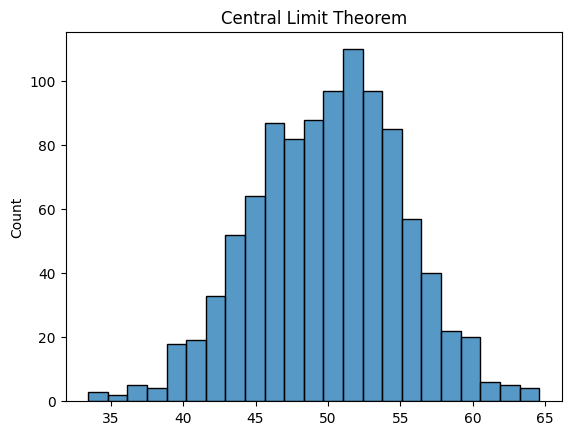

In [3]:

means = []

for i in range(1000):
    sample = np.random.randint(1,100,30)
    means.append(sample.mean())

sns.histplot(means)
plt.title("Central Limit Theorem")
plt.show()


## 2) 모집단 데이터 (비정규분포)
- 원래 데이터는 정규분포가 아님 → 오른쪽으로 치우친 분포

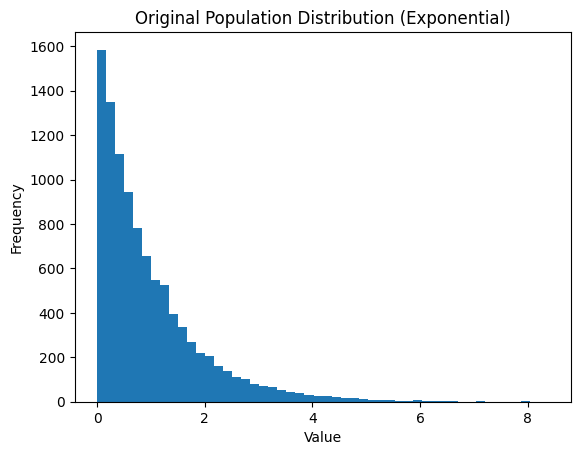

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 모집단 데이터 (비정규분포)
population = np.random.exponential(scale=1, size=10000)

plt.figure()
plt.hist(population, bins=50)
plt.title("Original Population Distribution (Exponential)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

## 3) 표본 평균 분포 (n=30)

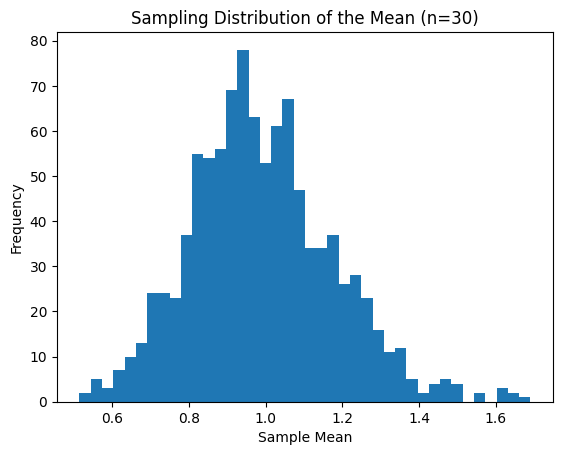

In [2]:
means = []

for i in range(1000):
    sample = np.random.exponential(scale=1, size=30)
    means.append(sample.mean())

plt.figure()
plt.hist(means, bins=40)
plt.title("Sampling Distribution of the Mean (n=30)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

## 4) 표본 크기 증가에 따른 변화

n=5
sample mean: 0.9916562747009892
sample std : 0.43645642000162715
theoretical std: 0.4472135954999579



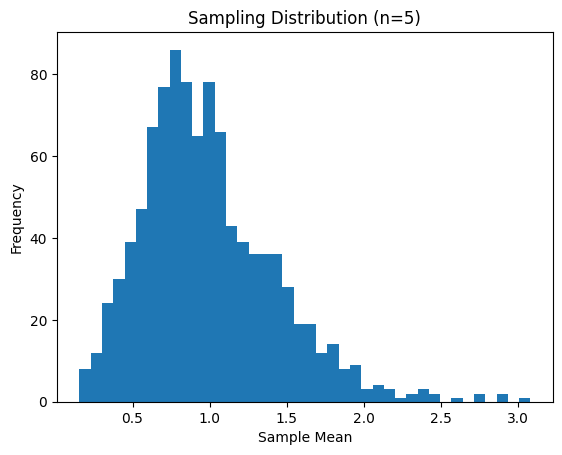

n=30
sample mean: 1.0053396394455223
sample std : 0.18703944470627654
theoretical std: 0.18257418583505536



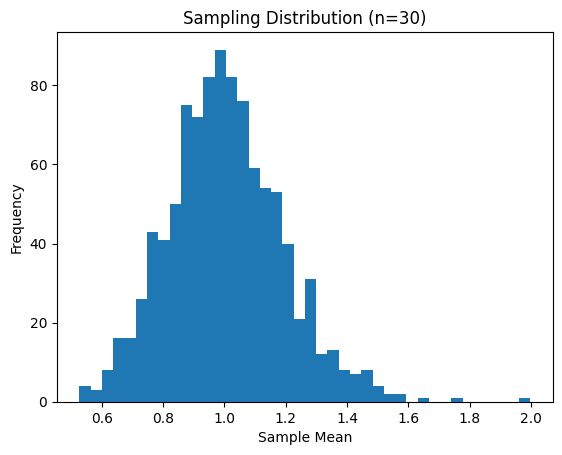

n=1,000,000
sample mean: 0.9999959665795863
sample std : 0.0010223251778080631
theoretical std: 0.001



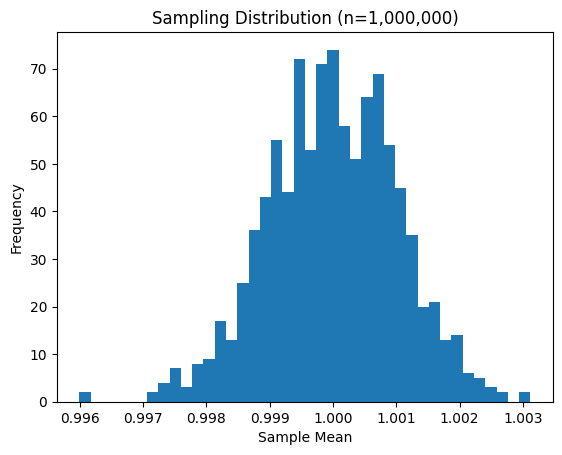

In [7]:
import numpy as np
import matplotlib.pyplot as plt

means_5 = []
means_30 = []
means_big = []

for i in range(1000):
    means_5.append(np.random.exponential(scale=1, size=5).mean())
    means_30.append(np.random.exponential(scale=1, size=30).mean())
    means_big.append(np.random.exponential(scale=1, size=1_000_000).mean())

# numpy array 변환
means_5 = np.array(means_5)
means_30 = np.array(means_30)
means_big = np.array(means_big)

# 모집단 평균과 표준편차 (exponential scale=1)
mu = 1
sigma = 1

# ---------- n=5 ----------
print("n=5")
print("sample mean:", means_5.mean())
print("sample std :", means_5.std())
print("theoretical std:", sigma/np.sqrt(5))
print()

plt.figure()
plt.hist(means_5, bins=40)
plt.title("Sampling Distribution (n=5)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()


# ---------- n=30 ----------
print("n=30")
print("sample mean:", means_30.mean())
print("sample std :", means_30.std())
print("theoretical std:", sigma/np.sqrt(30))
print()

plt.figure()
plt.hist(means_30, bins=40)
plt.title("Sampling Distribution (n=30)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()


# ---------- n=1,000,000 ----------
print("n=1,000,000")
print("sample mean:", means_big.mean())
print("sample std :", means_big.std())
print("theoretical std:", sigma/np.sqrt(1_000_000))
print()

plt.figure()
plt.hist(means_big, bins=40)
plt.title("Sampling Distribution (n=1,000,000)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

# 6. 신뢰구간 (Confidence Interval)

신뢰구간은 **모집단 평균이 존재할 것으로 예상되는 범위**입니다.

예

평균 = 70kg

95% 신뢰구간

68kg ~ 72kg

의미

모집단 평균이 이 범위 안에 있을 가능성이 높다.


표본평균: 69.48
95% 신뢰구간: (68.58, 70.38)


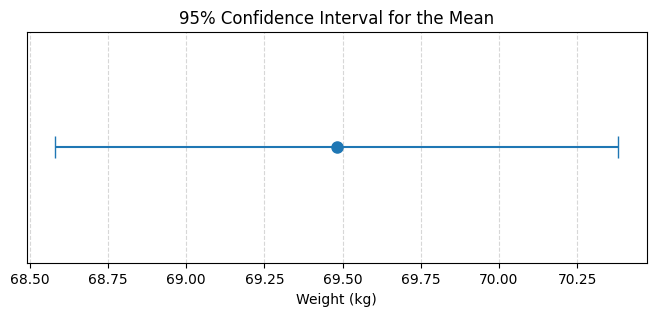

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 예시 데이터
np.random.seed(42)
data = np.random.normal(loc=70, scale=5, size=100)

# 통계량 계산
n = len(data)
sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1)
se = sample_std / np.sqrt(n)

confidence = 0.95
t_value = stats.t.ppf((1 + confidence) / 2, df=n - 1)
margin_error = t_value * se

ci_lower = sample_mean - margin_error
ci_upper = sample_mean + margin_error

print(f"표본평균: {sample_mean:.2f}")
print(f"95% 신뢰구간: ({ci_lower:.2f}, {ci_upper:.2f})")

# 그래프
plt.figure(figsize=(8, 3))
plt.errorbar(
    x=sample_mean,
    y=0,
    xerr=margin_error,
    fmt='o',
    capsize=8,
    markersize=8
)

plt.yticks([])
plt.xlabel("Weight (kg)")
plt.title("95% Confidence Interval for the Mean")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

데이터 범위: (56.90, 79.26)
표본평균: 69.48
95% 신뢰구간: (68.58, 70.38)


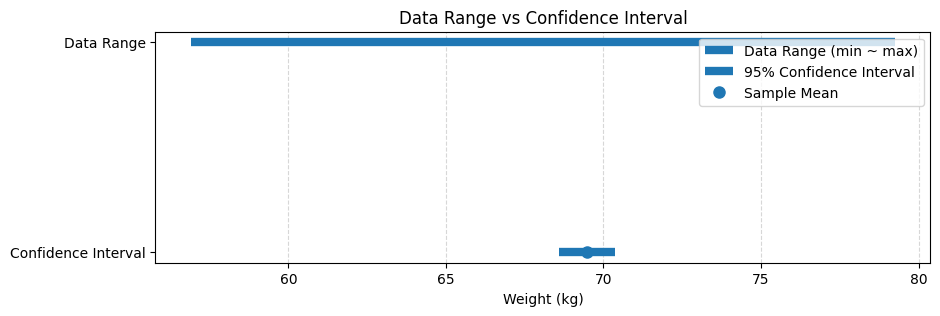

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 예시 데이터
np.random.seed(42)
data = np.random.normal(loc=70, scale=5, size=100)

# 통계량 계산
n = len(data)
sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1)
se = sample_std / np.sqrt(n)

confidence = 0.95
t_value = stats.t.ppf((1 + confidence) / 2, df=n - 1)
margin_error = t_value * se

ci_lower = sample_mean - margin_error
ci_upper = sample_mean + margin_error

data_min = np.min(data)
data_max = np.max(data)

print(f"데이터 범위: ({data_min:.2f}, {data_max:.2f})")
print(f"표본평균: {sample_mean:.2f}")
print(f"95% 신뢰구간: ({ci_lower:.2f}, {ci_upper:.2f})")

plt.figure(figsize=(10, 3))

# 데이터 전체 범위
plt.hlines(y=1, xmin=data_min, xmax=data_max, linewidth=6, label="Data Range (min ~ max)")

# 신뢰구간
plt.hlines(y=0, xmin=ci_lower, xmax=ci_upper, linewidth=6, label="95% Confidence Interval")
plt.plot(sample_mean, 0, 'o', markersize=8, label="Sample Mean")

plt.yticks([0, 1], ["Confidence Interval", "Data Range"])
plt.xlabel("Weight (kg)")
plt.title("Data Range vs Confidence Interval")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [8]:

import scipy.stats as stats

data = np.random.normal(70,5,100)

stats.t.interval(
    0.95,
    len(data)-1,
    loc=np.mean(data),
    scale=stats.sem(data)
)


(np.float64(68.76529929345483), np.float64(70.9672220176974))

# 7. 가설검정 (Hypothesis Testing)
가설검정은 **표본 데이터를 이용하여 모집단에 대한 주장(가설)이 맞는지 통계적으로 판단하는 방법**이다.  
현실에서는 모집단 전체를 조사하기 어렵기 때문에, 일부 표본 데이터를 기반으로 **모집단의 특성을 추론**하게 된다.

가설검정의 목적은 **관찰된 차이나 효과가 우연에 의해 발생한 것인지, 아니면 실제로 의미 있는 차이인지 판단하는 것**이다.



## 1) 가설검정이 필요한 이유

데이터 분석에서는 두 집단의 평균이나 비율이 서로 다르게 나타나는 경우가 많다.  
하지만 이런 차이가 항상 **실제 차이 때문이라고 단정할 수는 없다.**

예를 들어,

- A반 평균 점수: 82점  
- B반 평균 점수: 85점  

두 집단의 평균이 3점 차이가 나지만, 이 차이가

- 실제 교육 방식의 차이 때문인지  
- 단순히 표본이 우연히 그렇게 선택된 것인지  

판단하기 어렵다.

가설검정은 이러한 상황에서 **관찰된 차이가 우연으로도 발생할 수 있는 수준인지 판단하는 방법**이다.



---

## 2) 가설의 종류

가설검정에서는 두 가지 가설을 설정한다.

### (1) 귀무가설 (Null Hypothesis, $(H_0)$)

귀무가설은 **차이가 없다**, **효과가 없다**, **관계가 없다**는 기본 가설이다.

예시

$H_0: \mu_A = \mu_B$

즉, 두 집단의 평균은 같다고 가정한다.

---

### (2) 대립가설 (Alternative Hypothesis, $(H_1)$ 또는 $(H_a)$)

대립가설은 귀무가설과 반대되는 주장이다.

예시

$H_1: \mu_A \ne \mu_B$

즉, 두 집단의 평균이 서로 다르다는 가설이다.

---



## 3) 가설검정의 기본 아이디어

가설검정의 핵심은 다음과 같은 사고방식이다.

1. 먼저 **귀무가설이 참이라고 가정한다.**
2. 표본 데이터를 통해 관찰된 결과가 **얼마나 드문지 계산한다.**
3. 만약 그 결과가 **우연히 발생하기 어려운 수준이라면 귀무가설을 기각한다.**

즉, 가설검정은

> 귀무가설이 맞다고 가정했을 때 현재 데이터가 얼마나 비정상적인지를 판단하는 과정이다.

---



## 4) p-value

p-value는 가설검정에서 매우 중요한 값이다.

p-value는

> **귀무가설이 참이라고 가정했을 때, 현재와 같은 극단적인 결과가 나타날 확률**

을 의미한다.

예를 들어 p-value가 0.03이라면

- 귀무가설이 참인데도
- 현재와 같은 결과가 나올 확률이 **3%**

라는 의미이다.

이 값이 매우 작다면 **귀무가설이 맞다고 보기 어렵다**고 판단하게 된다.

---



## 5) 유의수준 (Significance Level)

유의수준은 **귀무가설을 기각할 기준이 되는 확률**이다.

보통 다음 값을 사용한다.

$\alpha = 0.05$

즉,

> 귀무가설이 실제로 참인데도 잘못 기각할 확률을 5%까지 허용한다.

---



## 6) 가설검정의 판단 기준

가설검정에서는 **p-value와 유의수준($\alpha$, significance level)**을 비교하여 귀무가설을 기각할지 여부를 결정한다.

유의수준은 보통 다음과 같이 설정한다.

$\alpha = 0.05$

이는 **귀무가설이 실제로 참인데도 잘못 기각할 확률을 5%까지 허용한다**는 의미이다.



### (1) p-value < $\alpha$

p-value가 유의수준보다 작으면 **귀무가설을 기각한다.**

즉,

- 통계적으로 유의하다 (statistically significant)
- 관찰된 차이나 효과가 **우연히 발생했다고 보기 어렵다**
- 따라서 **두 집단 사이에 차이가 존재한다고 판단한다**



### (2) p-value ≥ $\alpha$

p-value가 유의수준보다 크거나 같으면 **귀무가설을 기각하지 못한다.**

즉,

- 통계적으로 유의하지 않다
- 관찰된 차이가 **우연에 의해 발생했을 가능성을 배제할 수 없다**
- 따라서 **두 집단 사이에 차이가 있다고 결론 내리기 어렵다**

주의할 점은 **귀무가설을 채택한다(accept)** 라기보다는  
**귀무가설을 기각하지 못한다(fail to reject)** 라고 표현하는 것이 더 정확하다.



## p-value의 의미

p-value는 가설검정에서 매우 중요한 개념이다.

p-value는 다음과 같이 정의된다.

> **귀무가설이 참이라고 가정했을 때, 현재와 같거나 그보다 더 극단적인 결과가 나타날 확률**

예를 들어, 

p-value = 0.03

이라면

- 귀무가설이 실제로 참인데도
- 지금과 같은 결과가 나타날 확률이 **3%**라는 의미이다.

따라서 이런 결과는 **우연히 발생하기 어려운 결과**라고 해석할 수 있다.



## p-value 해석 기준 (일반적인 기준)

| p-value | 해석 |
|--------|------|
| < 0.05 | 통계적으로 유의하다 (귀무가설 기각) |
| ≥ 0.05 | 통계적으로 유의하지 않다 (귀무가설 기각하지 못함) |

---

## 핵심 정리

가설검정에서는 **p-value와 유의수준을 비교하여 결론을 내린다.**

- **p-value < $\alpha$** → 귀무가설 기각 → 차이가 존재한다고 판단  
- **p-value ≥ $\alpha$** → 귀무가설 기각하지 못함 → 차이가 있다고 보기 어려움



---



## 7) 가설검정의 절차

가설검정은 일반적으로 다음 단계로 진행된다.

1. 가설 설정 (귀무가설, 대립가설)
2. 유의수준 설정
3. 검정통계량 계산
4. p-value 계산
5. 귀무가설 기각 여부 판단

---



## 8) 단측검정과 양측검정

### (1) 양측검정 (Two-tailed test)

두 집단 간 **차이가 있는지만** 확인하는 검정이다.

$ H_1: \mu_A \ne \mu_B $

예: 두 집단 평균이 서로 다른가?



### (2) 단측검정 (One-tailed test)

한 방향으로 **더 크거나 작은지**를 확인하는 검정이다.

$ H_1: \mu_A > \mu_B $

또는

$ H_1: \mu_A < \mu_B $

예: 새로운 교육 방법이 기존 방법보다 **더 효과적인가?**

---


## 9) 가설검정에서 발생할 수 있는 오류

가설검정에서는 결정을 내리는 과정에서 **두 가지 종류의 오류가 발생할 수 있다.**



### (1) Type I Error (제1종 오류)

**귀무가설이 실제로 참인데도 귀무가설을 기각하는 오류**

즉,

- 실제로는 차이가 없는데
- 차이가 있다고 판단하는 경우

예시

- 정상 거래를 **사기 거래로 판단**
- 검사 결과 **정상인데 암이라고 진단**



### (2) Type II Error (제2종 오류)

**귀무가설이 실제로 거짓인데도 귀무가설을 기각하지 못하는 오류**

즉,

- 실제로는 차이가 있는데
- 차이가 없다고 판단하는 경우

예시

- 사기 거래를 **정상 거래로 판단**
- 검사 결과 **암인데 정상이라고 판단**



### (3) Type I / Type II Error 정리

| 실제 상태 | 통계적 판단 | 결과 |
|-----------|-------------|------|
| 귀무가설 참 | 귀무가설 기각 | Type I Error |
| 귀무가설 거짓 | 귀무가설 기각하지 못함 | Type II Error |



## 핵심 정리

- **Type I Error**  
  실제로 차이가 없는데 차이가 있다고 판단하는 오류  

- **Type II Error**  
  실제로 차이가 있는데 차이가 없다고 판단하는 오류


## 정리

가설검정은 **표본 데이터를 이용하여 모집단에 대한 가설이 맞는지 판단하는 통계적 방법**이다.

- 귀무가설: 차이가 없다
- 대립가설: 차이가 있다
- p-value: 현재 결과가 우연히 발생할 확률
- p-value < α 이면 귀무가설을 기각한다.

# 8. t-test / ANOVA

가설검정의 대표적인 평균 비교 방법입니다.


t-test와 ANOVA 같은 통계 검정은 다음 이론을 기반으로 합니다.

1. 데이터 분포 (특히 정규분포)
2. 중심극한정리
3. p-value
4. Type I / Type II error

이 개념들을 이해한 후 가설검정을 보면 **왜 이런 검정을 사용하는지** 이해하기 쉬워집니다.


## 1) 가설 검정 t-test
* t-test는 두 집단의 평균을 비교해서 차이가 있는지 확인하는 통계적 방법
* t 통계량의 절대값이 크면 p-value(유의 수준)가 낮아짐


### (1) 일 표본 단측 t-검정(한 쪽으로 방향성을 갖는 경우)
* 모수에 대한 검정을 할 때 모수 값이 **~보다 크다, ~보다 작다**와 같이 한쪽으로 방향성을 갖는 경우 수행되는 검정 방법
* 00공장에서 생산되는 지우개의 평균 중량은 50g 이하다.(귀무가설) - 원래 알고있던 사실
* 00공장에서 생산되는 지우개의 평균 중량은 50g 초과다.(대립가설) - 새로운 주장

In [ ]:
# 통계와 회귀분석에 특화되어 있는 라이브러리
# !pip install statsmodels

In [42]:
import statsmodels.stats.weightstats as stests
from scipy import stats

In [43]:
# 일 표본 단측 t-test를 위해서 지우개 10개의 표본 추출
weights = np.random.uniform(49, 52, 10)
print(weights)
print("지우개의 평균 ", weights.mean())

[50.60924914 51.93310912 49.77813591 49.59232051 50.92240477 51.08581361
 50.58685163 49.91751672 51.3535001  51.6995657 ]
지우개의 평균  50.74784672200792


In [44]:
# stats.ttest_1samp(weights, 50, alternative='greater')

TtestResult(statistic=np.float64(2.937748702597274), pvalue=np.float64(0.008273594893838714), df=np.int64(9))

In [45]:
# 일 표본 단측 t-test 크다, 작다
t_stat, p_value = stats.ttest_1samp(weights, 50, alternative='greater')
print(f"t-통계량: {t_stat}, p-value: {p_value}")

t-통계량: 2.937748702597274, p-value: 0.008273594893838714


* p-value가 0.008이므로 유의수준 0.05 보다 작기 때문에<br>
귀무가설(지우개의 무게는 50g 이하다)은 기각<br>
대립가설(지우개의 무게는 50g 초과다)은 채택<br>

### (2) 일 표본 양측 t-test(방향성이 없는 경우) 맞다, 아니다
* 단측 검정과 달리 모수 값이 **~이다, ~가 아니다** 와 같이 방향성이 없는 경우.
* 대한민국 남성의 평균 몸무게는 70kg이다. (귀무가설)
* 대한민국 남성의 평균 몸무게는 70kg이 아니다. (대립가설)

In [46]:
# 일 표본 양측 t-test를 위한 40kg-100kg 사이 남성 100명 표본을 추출
weights = np.random.uniform(40, 100, 100)
print(len(weights))
print("몸무게 평균 ", weights.mean())

100
몸무게 평균  70.50921515845326


In [47]:
# 일 표본 양측 t-test
t_stat, p_value = stats.ttest_1samp(weights, 70, alternative='two-sided')
print(f"t-통계량: {t_stat}, p-value: {p_value}")

t-통계량: 0.30202459938022835, p-value: 0.7632668825728526


* 대한민국 남성의 평균 몸무게는 70kg이다. (귀무가설)
* 대한민국 남성의 평균 몸무게는 70kg이 아니다. (대립가설)
* p-value가 0.76 이므로 유의수준 0.05보다 큼
* 따라서 대한민국 남성의 평균 몸무게는 70kg이다. 라는 귀무가설 채택


### (3) 이 표본 단측 t 검정 (~보다 크다 / 작다)
* 두 집단에 대해서 모수 비교를 할 때 A가 B보다 크다/작다를 비교하는 검정
* A회사의 급여가 B회사의 급여보다 같거나 많다.

### (4) 이 표본 양측 t 검정 (A와 B가 같다/다르다)
* 두 집단에 대해서 모수 비교를 할 때 A와 B가 같다/다르다 를 비교하는 검정
* A회사의 급여와 B회사의 급여가 같다/다르다

### (5)  대응 표본 t검정(paired t-test) A/B test
* 실험 전후 비교
* 동일한 대상에 대해 두 가지 관측치가 있는 경우 이를 비교하여 차이가 있는지 검정할 때 사용
* 두 집단에 신약 투여 후 전후 수치 비교, 새로운 버전의 앱/ 기능 추가 전후 비교
* 새로운 운동법이 체중 감량 효과가 있는지 검증하기 위해서 새로운 운동법을 실시한 집단과 실시하지 않은 집단의 체중 비교
* 새로운 운동법으로 체중감량의 효과는 없다.(귀무가설) 운동전 무게와 운동 후 무게 >= 0
* 새로운 운동법으로 체중감량의 효과가 있다.(대립가설) 운동전 무게와 운동 후 무게 
< 0

In [49]:
# 대응 표본 t검정을 위한 표본 추출
before = np.random.uniform(60, 80, 100)
after = before + np.random.normal(-3, 2, 100)

# 대응 표본 t검정
t_stat, p_value = stats.ttest_rel(before, after, alternative="greater")
print(f"t-통계량: {t_stat}, p-value: {p_value}")

t-통계량: 14.083750792034444, p-value: 1.1087249058419754e-25


* p-value가 0.05 미만이므로<br>
귀무가설(새로운 운동법으로 체중감량의 효과는 없다.)은 기각<br>
대립가설(새로운 운동법으로 체중감량의 효과가 있다.)채택 <br>

## 2) 분산분석(ANOVA)
* 3개 이상의 모집단 있을 경우 집단 사이의 평균 비교
* 분산분석의 귀무가설($ H_0 $) "모든 집단 간 평균은 같다"
* 1) 분산 분석을 수행하기 위해서는 3가지 가정이 필요.
  * 정규성: 각 집단의 표본들을 정규분포를 따라야 한다.
  * 등분산성: 각 집단은 동일한 분산을 가져야 한다.
  * 독립성: 각 집단은 서로에게 영향을 주지 않는다.
* 2) 분산 분석
  * 분산분석의 독립변수는 범주형 데이터, 종속변수는 연속형이어야 한다.
  * 분산분석에는 '(집단 간 분산)/(집단 내 분산)'으로 계산되는 F-value가 사용.
  * F-value가 커지면 p-value가 작아진다.
  * 평균을 비교하는 분석에 '분산'의 개념을 사용하는 이유는 집단 간 평균의 분산이 클 수록 각 집단의 평균은 서로 멀리 떨어져 있기 때문에 집단 간 차이를 비교하기 쉬워진다.

### (1) 일원분산분석(one-way ANOVA)
* 셋 이상의 집단 간 평균을 비교하는 상황에서 하나의 집단에 속하는 독립변수와 종속변수가 모두 한 개일 때 사용
  * 독립변수 1: 연령별 집단(청소년, 성인, 노인) - 범주형
  * 종속변수 1: 유투브 시청 시간 - 연속형
  
* 신형 휴대폰 A, B, C의 속도 차이가 있는지 여부
* 귀무가설($ H_0 $): A, B, C 세 대의 신형 휴대폰 간의 속도 차이는 없다.
* 대립가설($ H_1 $): A, B, C 세 대의 신형 휴대폰 간의 속도 차이는 있다.

In [50]:
# 분산분석을 위한 데이터 생성
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [52]:
np.random.seed(0)
phone_speed = np.random.uniform(75, 100, 45)
telecom = np.tile(['A', 'B', 'C'], 15)
print("phone_speed ", phone_speed)
print("telecom ", telecom)

phone_speed  [88.7203376  92.87973416 90.0690844  88.62207957 85.59136998 91.14735283
 85.93968028 97.29432502 99.09156901 84.58603797 94.79312595 88.22237299
 89.20111403 98.13991596 76.77590145 77.17823249 75.50545994 95.81549614
 94.45391877 96.75030371 99.46545856 94.97896411 86.53698406 94.51322941
 77.95686065 90.99802553 78.58383219 98.61672293 88.04620804 85.3665485
 81.6138903  94.35584224 86.40375831 89.21084872 75.46974501 90.44088743
 90.30239307 90.42334992 98.59370196 92.04550748 83.98769751 85.92579884
 92.4407799  76.50563679 91.66916789]
telecom  ['A' 'B' 'C' 'A' 'B' 'C' 'A' 'B' 'C' 'A' 'B' 'C' 'A' 'B' 'C' 'A' 'B' 'C'
 'A' 'B' 'C' 'A' 'B' 'C' 'A' 'B' 'C' 'A' 'B' 'C' 'A' 'B' 'C' 'A' 'B' 'C'
 'A' 'B' 'C' 'A' 'B' 'C' 'A' 'B' 'C']


In [53]:
phone_data = pd.DataFrame(dict(phone_speed=phone_speed, telecom=telecom))
phone_data

,phone_speed,telecom
0,88.720338,A
1,92.879734,B
2,90.069084,C
3,88.622080,A
4,85.591370,B
5,91.147353,C
6,85.939680,A
7,97.294325,B
8,99.091569,C
9,84.586038,A


In [57]:
# 분산 분석 수행
# 선형회귀분석
model = ols('phone_speed ~ C(telecom)', data=phone_data).fit()
print(model.summary())
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                            OLS Regression Results                            
Dep. Variable:            phone_speed   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                 -0.033
Method:                 Least Squares   F-statistic:                    0.2983
Date:                Wed, 07 May 2025   Prob (F-statistic):              0.744
Time:                        13:44:49   Log-Likelihood:                -149.68
No. Observations:                  45   AIC:                             305.4
Df Residuals:                      42   BIC:                             310.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          88.3912      1.800     

* 신형 휴대폰 A, B, C의 속도 차이가 있는지 여부
* **귀무가설($ H_0 $): A, B, C 세 대의 신형 휴대폰 간의 속도 차이는 없다.(0.743638 > 0.05)** 채택
* 대립가설($ H_1 $): A, B, C 세 대의 신형 휴대폰 간의 속도 차이는 있다.(< 0.05) 기각

# 9. 머신러닝 평가

## Confusion Matrix와 Type I / Type II Error

머신러닝 분류 문제에서는 예측 결과를 다음과 같이 해석합니다.

- True Positive
- True Negative
- False Positive
- False Negative

이는 통계학의 Type I / Type II error와도 연결됩니다.


| Confusion Matrix | 통계 오류 |
|:---:|:---:|
|False Positive|Type I error|
|False Negative|Type II error|

## Confusion Matrix와 통계 오류 대응

| 실제 | 예측 | Confusion Matrix | 통계 오류 |
|---|---|---|---|
| 정상 (Negative) | 정상 (Negative) | True Negative (TN) | 정상 판단 |
| 정상 (Negative) | 이상 (Positive) | False Positive (FP) | Type I Error |
| 이상 (Positive) | 정상 (Negative) | False Negative (FN) | Type II Error |
| 이상 (Positive) | 이상 (Positive) | True Positive (TP) | 정상 탐지 |

### 오류 유형 요약

| 오류 유형 | 설명 | 예시 |
|---|---|---|
| Type I Error | 실제 정상인데 이상으로 판단 | 정상 이메일 → 스팸 |
| Type II Error | 실제 이상인데 정상으로 판단 | 암 환자 → 정상 |

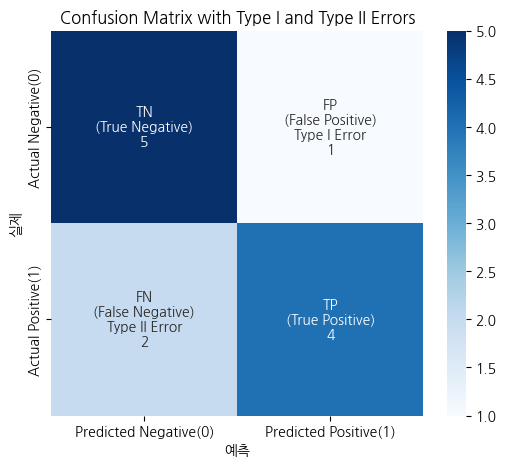

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import koreanize_matplotlib

# 예제 데이터
y_true = [1,0,1,1,0,0,1,0,1,0,1,0]
y_pred = [1,0,0,1,0,1,1,0,1,0,0,0]

# Confusion Matrix 계산
cm = confusion_matrix(y_true, y_pred)

# annotation 텍스트 생성
labels = np.array([
    ["TN\n(True Negative)",
     "FP\n(False Positive)\nType I Error"],

    ["FN\n(False Negative)\nType II Error",
     "TP\n(True Positive)"]
])

# 값 + 설명 합치기
annot = np.empty_like(labels, dtype=object)

for i in range(2):
    for j in range(2):
        annot[i,j] = f"{labels[i,j]}\n{cm[i,j]}"

# 그래프 그리기
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=annot,
    fmt="",
    cmap="Blues",
    xticklabels=["Predicted Negative(0)","Predicted Positive(1)"],
    yticklabels=["Actual Negative(0)","Actual Positive(1)"]
)

plt.title("Confusion Matrix with Type I and Type II Errors")
plt.ylabel("실제")
plt.xlabel("예측")

plt.show()

# 10. 머신러닝 통계 핵심

## 1) Bias
- 모델이 너무 단순해서 실제 패턴을 충분히 학습하지 못하는 경향
- 편향이 크면 **체계적으로 틀리는 방향**이 생김

## 2) Variance
- 모델이 훈련 데이터의 작은 변화에도 크게 흔들리는 경향
- 분산이 크면 **훈련 데이터에 과하게 맞춤**

## 3) Underfitting
- 모델이 너무 단순해서 훈련 데이터도 잘 설명하지 못하는 상태
- 보통 **Bias가 큰 상태**와 연결됨

## 4) Overfitting
- 훈련 데이터에는 잘 맞지만 새로운 데이터에는 성능이 떨어지는 상태
- 보통 **Variance가 큰 상태**와 연결됨

## 5) Bias-Variance Tradeoff
- Bias를 너무 줄이려 하면 Variance가 커질 수 있음
- Variance를 너무 줄이려 하면 Bias가 커질 수 있음
- 좋은 모델은 두 값을 적절히 균형 잡음

정리
- 단순한 모델 → Bias ↑ / Variance ↓
- 복잡한 모델 → Bias ↓ / Variance ↑


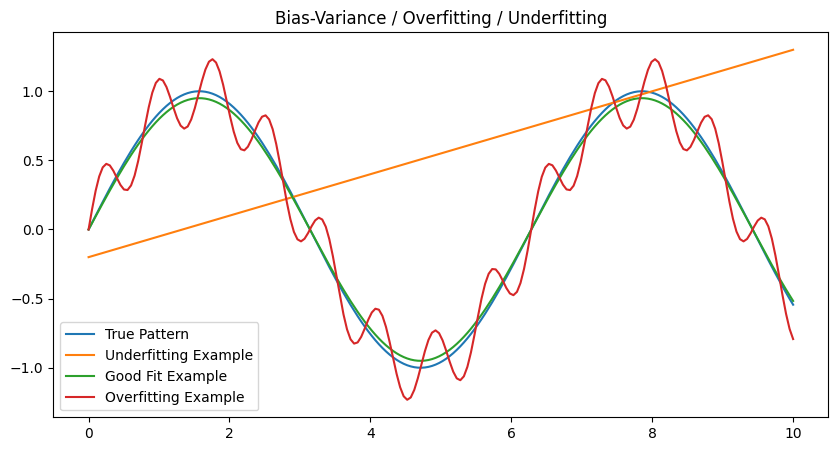

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 200)
true_y = np.sin(x)
underfit_y = 0.15 * x - 0.2
goodfit_y = np.sin(x) * 0.95
overfit_y = np.sin(x) + 0.25 * np.sin(8 * x)

plt.figure(figsize=(10, 5))
plt.plot(x, true_y, label='True Pattern')
plt.plot(x, underfit_y, label='Underfitting Example')
plt.plot(x, goodfit_y, label='Good Fit Example')
plt.plot(x, overfit_y, label='Overfitting Example')
plt.legend()
plt.title('Bias-Variance / Overfitting / Underfitting')
plt.show()
